<a href="https://colab.research.google.com/github/ErenB02/compneuro/blob/main/projects/ECoG/Finger_Flex_EDA_SHARE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FingerFlex ECoG — EDA

**Dataset.** Kai Miller FingerFlex ECoG (Miller 2009): 3 subjects performing cued single-finger flexions, with a simultaneous 5-DOF dataglove sampled at 1000 Hz alongside the cortical voltage. This distilled EDA runs the full pipeline on **subject 0** (the reference subject).

**What this EDA establishes.** (1) a validated movement-onset time (t=0) exists for each trial, taken from the glove rather than the cue; (2) the cued label and the glove-observed label are kept side by side with a per-trial dominance margin, never overwritten; (3) the five fingers show biomechanical coupling during movement, with the ring finger coupling to its neighbours (middle, little). It ends with the open labeling decisions for the group.


### Environment Setup
Install necessary dependencies and loads specific Miller dataset session (`dat2`).

In [1]:
# Uncomment to install requirements:
!pip install -q mne pyvista trame trame-vtk trame-vuetify ipympl
!pip install mne nbformat --quiet
# get_ipython().kernel.do_shutdown(restart=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.4/853.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [2]:
# Run to import packages and set up backend
# from google.colab import output
# output.enable_custom_widget_manager()

%matplotlib inline
# static PNGs embed in the notebook and persist on save/reopen
# (use '%matplotlib widget' for a live interactive session, but those figures do NOT save)
import numpy as np
import os
import requests
import matplotlib.pyplot as plt

# Signal processing
from scipy.stats import kurtosis
from scipy.signal import butter, filtfilt, hilbert, welch, convolve
from scipy.ndimage import gaussian_filter1d

# Optional: MNE for advanced ECoG tools
import mne
import pyvista as pv
from IPython import core, get_ipython

pv.set_jupyter_backend("trame")
mne.viz.set_browser_backend("matplotlib")

Using matplotlib as 2D backend.


### Data Loading

### Global Configuration
All tuneable parameters for the notebook live here. Edit once, used everywhere.

In [3]:
# GLOBAL CONFIGURATION — edit these once, used throughout

SUBJ            = 0                              # Subject to analyse (0, 1, or 2)
FINGER_NAMES    = ['thumb', 'index', 'middle', 'ring', 'little']
N_FINGERS       = len(FINGER_NAMES)

# Frequency bands (Hz)
BROADBAND_BAND  = (70, 150)                      # High-gamma
BETA_BAND       = (12, 20)                       # Lower beta (matches original MATLAB code)

# Signal processing
SMOOTH_MS       = 50                             # Gaussian smoothing kernel width (ms)
BUTTER_ORDER    = 4                              # Butterworth filter order

# Onset detection
BASELINE_S      = 0.5                            # Pre-cue baseline window (seconds)
TRIAL_S         = 2.0                            # Post-cue trial window (seconds)
ONSET_SD_MULT   = 3.0                            # Threshold = baseline_mean + N * SD
ONSET_SUSTAIN_MS = 40                            # Sustained above threshold (ms)
MIN_LATENCY_MS  = 150                            # Physiological floor: exclude anticipatory onsets
MAX_LATENCY_MS  = 2000                           # Physiological ceiling: exclude non-responses

LOW_MARGIN_THRESHOLD = 0.10                      # margin below this = coupled near-tie, excluded from final_label


In [4]:
redownload = False
fname = 'fingerflex.npz'
url = "https://osf.io/5m47z/download"


In [5]:
# Run cell to download sample data


if os.path.isfile(fname) and redownload:
    print(f"Removing existing {fname}...")
    os.remove(fname)

print(f"Downloading {fname} (this may take a moment)...")
try:
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(fname, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print("Download complete.")

    # Test the file immediately
    with np.load(fname, allow_pickle=True) as data:
        alldat = data['dat'][0]
        print(f"Success! Data loaded. Keys: {list(data.keys())}")
except Exception as e:
    print(f"!!! Error: {e} !!!")


Download complete.
Success! Data loaded. Keys: ['dat']


### Helper Functions & Signal Processing Math

We modularise our pipeline into three distinct helper functions. The mathematical formulation and operational logic for each is detailed below:

#### 1. Band Amplitude Extraction (`extract_band_amplitude`)
This function processes the raw continuous ECoG voltage $V(t)$ to compute a smoothed, z-scored amplitude envelope in a target frequency band $[f_{low}, f_{high}]$:

- **Zero-Phase Bandpass Filter**: We apply a 4th-order Butterworth filter. To avoid introducing phase distortion (which would shift our envelopes in time relative to behavior), we use `scipy.signal.filtfilt`. This passes the signal forward and backward, cancelling any phase shift:  
  $$V_{bp}(t) = \text{filtfilt}(V(t))$$
- **Hilbert Envelope**: We construct the complex analytic signal $Z(t) = V_{bp}(t) + i \cdot \mathcal{H}[V_{bp}(t)]$, where $\mathcal{H}$ is the Hilbert transform. The instantaneous amplitude envelope is the magnitude of $Z(t)$:  
  $$A(t) = |Z(t)| = \sqrt{V_{bp}(t)^2 + \mathcal{H}[V_{bp}(t)]^2}$$
- **Gaussian Smoothing**: We convolve the raw envelope with a 1D Gaussian kernel to act as a low-pass filter (smoothing high-frequency ripple). The standard deviation $\sigma$ is calculated from the requested `smooth_ms` time constant:  
  $$A_{smooth}(t) = A(t) * g(t) \quad \text{where} \quad g(t) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{t^2}{2\sigma^2}}$$
- **Standard Normalization (Z-scoring)**: The smoothed envelope is normalised per channel across the entire recording to prevent electrodes with high baseline voltage from dominating the population statistics:  
  $$z(t) = \frac{A_{smooth}(t) - \mu}{\sigma}$$

#### 2. Movement Onset Detection (`detect_movement_onset`)
To find the exact timestamp a subject began moving their finger on a given trial, we analyze the corresponding glove flexion trace:

- **Baseline Estimation**: Using the pre-cue window (length $N_{base}$), we calculate the baseline mean $\mu_{base}$ and standard deviation $\sigma_{base}$ representing the rest state:  
  $$\mu_{base} = \frac{1}{N_{base}}\sum_{t=1}^{N_{base}} x(t), \quad \sigma_{base} = \sqrt{\frac{1}{N_{base}}\sum_{t=1}^{N_{base}} (x(t) - \mu_{base})^2}$$
- **Statistical Thresholding**: We set a threshold representing a significant departure from rest:  
  $$\text{Threshold} = \mu_{base} + k \cdot \sigma_{base} \quad (\text{typically } k = 3)$$
- **Sustained Flexion Criterion**: We scan the post-cue signal to find the first sample index $t_0$ where the glove flexion remains strictly above the threshold for a sustained duration $T_{sustained}$ (typically 40 ms) to avoid triggering on high-frequency noise spikes:  
  $$\text{Onset } t_0 = \min \{ t \ge N_{base} \mid x(\tau) > \text{Threshold} \text{ for all } \tau \in [t, t + T_{sustained}] \}$$

#### 3. Motor Channel Selector (`get_motor_channel`)
ECoG signals are highly localised. To analyze motor behavior, we target channels situated directly over primary motor (M1) or sensory (S1) cortex. This helper queries the anatomical channel metadata and returns the first channel index labeled as `Precentral Gyrus` or `Postcentral Gyrus`, falling back to channel 0 if the metadata is missing.

In [6]:
# HELPER FUNCTIONS — reusable building blocks for the pipeline

def extract_band_amplitude(V, srate, low_freq, high_freq,
                           smooth_ms=SMOOTH_MS, order=BUTTER_ORDER):
    """
    Extract the amplitude envelope of a specific frequency band.

    Pipeline:
      1. Band-pass filter (Butterworth, zero-phase)
      2. Hilbert transform → instantaneous amplitude envelope
      3. Gaussian smoothing (removes sample-to-sample jitter)
      4. Z-score per channel (normalises electrode differences)

    Parameters
    ----------
    V         : ndarray, shape (n_samples, n_channels) — continuous ECoG voltage
    srate     : int — sampling rate in Hz
    low_freq  : float — lower edge of the band (Hz)
    high_freq : float — upper edge of the band (Hz)
    smooth_ms : float — Gaussian kernel width in milliseconds
    order     : int — Butterworth filter order

    Returns
    -------
    ndarray, shape (n_samples, n_channels) — z-scored amplitude envelope
    """
    # 1. Band-pass filter (zero-phase: filtfilt applies forward + backward)
    b, a = butter(order, [low_freq, high_freq], btype='band', fs=srate)
    V_bp = filtfilt(b, a, V.astype(np.float32), axis=0)

    # 2. Hilbert envelope: analytic signal → take magnitude
    envelope = np.abs(hilbert(V_bp, axis=0))

    # 3. Smooth with Gaussian kernel (converts ms → samples)
    sigma_samples = (smooth_ms / 1000.0) * srate
    envelope_smooth = gaussian_filter1d(envelope, sigma=sigma_samples, axis=0)

    # 4. Z-score per channel: (x - mean) / std
    mu = envelope_smooth.mean(axis=0, keepdims=True)
    sd = envelope_smooth.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0  # guard against division by zero on dead channels

    return (envelope_smooth - mu) / sd


def detect_movement_onset(trace, pre_samples,
                          sd_multiplier=ONSET_SD_MULT,
                          sustained_ms=ONSET_SUSTAIN_MS):
    """
    Detect the first movement onset in a single-trial glove trace.

    Algorithm:
      1. Compute baseline mean and SD from the pre-cue window
         (the first `pre_samples` of the trace).
      2. Set threshold = mean + sd_multiplier * SD.
      3. Scan the post-cue portion for the first sample where
         the signal stays above threshold for `sustained_ms`
         consecutive samples.

    Parameters
    ----------
    trace        : 1-D array — glove flexion values for one trial
    pre_samples  : int — number of baseline samples before cue onset
    sd_multiplier: float — threshold = mean + N * SD
    sustained_ms : int — minimum consecutive samples above threshold

    Returns
    -------
    (onset_ms, threshold) — onset_ms is NaN if no onset detected
    """
    baseline = trace[:pre_samples]
    mu = np.mean(baseline)
    sd = np.std(baseline)
    threshold = mu + sd_multiplier * sd

    post_cue = trace[pre_samples:]

    for i in range(len(post_cue) - sustained_ms):
        if np.all(post_cue[i : i + sustained_ms] > threshold):
            return i, threshold      # i is directly in ms (srate = 1000 Hz)

    return np.nan, threshold


def get_motor_channel(subj_data, fallback=0):
    """
    Return the index of the first Precentral or Postcentral Gyrus channel.
    Falls back to `fallback` if none found.
    """
    gyri = subj_data.get('gyrus', np.array([]))
    motor_chs = np.where(
        (gyri == 'Precentral Gyrus') | (gyri == 'Postcentral Gyrus')
    )[0]
    return motor_chs[0] if len(motor_chs) > 0 else fallback


### Bad-channel detection
Flag dead / intermittently-flat / railed / spiky / noisy channels on every subject, to reject before referencing.


In [7]:
# BAD-CHANNEL DETECTION — all 4 detectors in a single pass
# We run four independent tests on every channel of every subject:
#   1. DEAD / FLAT — global variance is zero or NaN.
#   2. INTERMITTENT FLAT — >10% of 1-second windows have near-zero variance.
#   3. CLIPPED / RAILED — >1% of samples pinned at channel min or max.
#   4. SPIKY (kurtosis > 10) or NOISY (line-length z-score > 3 SD).
# Results are merged into a single `bad_channels` dict. We also save the
# continuous metrics themselves (not just the pass/fail flags) in
# `channel_metrics`, so we can visualize the distributions behind the
# cutoffs afterward instead of only seeing which channels got flagged.

bad_channels = {}
channel_metrics = {}

for subj in range(len(alldat)):
    V = alldat[subj]['V'].astype(np.float32)
    n_samples, n_ch = V.shape
    srate = int(alldat[subj]['srate'].item())

    print(f"\n{'='*50}")
    print(f"Subject {subj}  ({n_ch} channels, {n_samples/srate:.0f}s recording)")
    print(f"{'='*50}")

    # ── 1. Dead / flat (global variance) ──────────────────────────
    global_var = np.nanvar(V, axis=0)
    dead = set(np.where((global_var == 0) | np.isnan(global_var))[0])

    # ── 2. Intermittent flatlines (1-s sliding window) ───────────
    win = srate
    n_wins = n_samples // win
    local_vars = np.array([np.var(V[i*win:(i+1)*win, :], axis=0) for i in range(n_wins)])
    flat_frac = np.mean(local_vars < 0.01, axis=0)
    intermittent = set(np.where(flat_frac > 0.10)[0])

    # ── 3. Clipped / railed ──────────────────────────────────────
    ch_min = V.min(axis=0)
    ch_max = V.max(axis=0)
    railed = set()
    for ch in range(n_ch):
        at_min = np.mean(V[:, ch] == ch_min[ch])
        at_max = np.mean(V[:, ch] == ch_max[ch])
        if at_min + at_max > 0.01:
            railed.add(ch)

    # ── 4. Spiky (kurtosis) + Noisy (line-length) ────────────────
    kurt = kurtosis(V, axis=0, fisher=True)
    spiky = set(np.where(kurt > 10)[0])

    ll = np.mean(np.abs(np.diff(V, axis=0)), axis=0)
    ll_z = (ll - np.median(ll)) / np.std(ll)
    noisy = set(np.where(ll_z > 3)[0])

    # Save the continuous metrics for later visualization. Note: raw
    # channel variance itself is NOT saved for plotting — this dataset is
    # already z-scored per channel upstream (see dataset info above), so
    # global_var is ~1.0 for every channel and a histogram of it would be
    # a single uninformative spike. flat_frac, kurtosis, and line-length
    # z-score are the three metrics that actually vary meaningfully here.
    channel_metrics[subj] = {
        'flat_frac': flat_frac,
        'kurtosis': kurt,
        'line_length_z': ll_z,
    }

    # ── Merge all flags ──────────────────────────────────────────
    all_bad = sorted(dead | intermittent | railed | spiky | noisy)
    bad_channels[subj] = all_bad

    if all_bad:
        print(f"  {len(all_bad)}/{n_ch} channels flagged: {all_bad}")
        for ch in all_bad:
            reasons = []
            if ch in dead:         reasons.append("dead")
            if ch in intermittent: reasons.append("flat")
            if ch in railed:       reasons.append("railed")
            if ch in spiky:        reasons.append("spiky")
            if ch in noisy:        reasons.append("noisy")
            print(f"    ch {ch:3d}: " + ", ".join(reasons))
    else:
        print(f"  All {n_ch} channels clean")

print(f"\n--- bad_channels dict saved for downstream use ---")



Subject 0  (84 channels, 610s recording)
  All 84 channels clean

Subject 1  (64 channels, 610s recording)
  2/64 channels flagged: [np.int64(43), np.int64(53)]
    ch  43: flat, spiky
    ch  53: noisy

Subject 2  (80 channels, 445s recording)
  2/80 channels flagged: [np.int64(33), np.int64(34)]
    ch  33: spiky
    ch  34: flat, spiky

--- bad_channels dict saved for downstream use ---


### Figure 0 — Bad-channel QC metric distributions
Histograms of the three continuous metrics that actually vary across channels in this dataset (`flat_frac`, `kurtosis`, `line-length z-score`), with each detector's cutoff overlaid. Raw channel variance is excluded here — the data arrives already z-scored per channel (see dataset info at the top), so variance is ~1.0 for every channel and uninformative to plot.


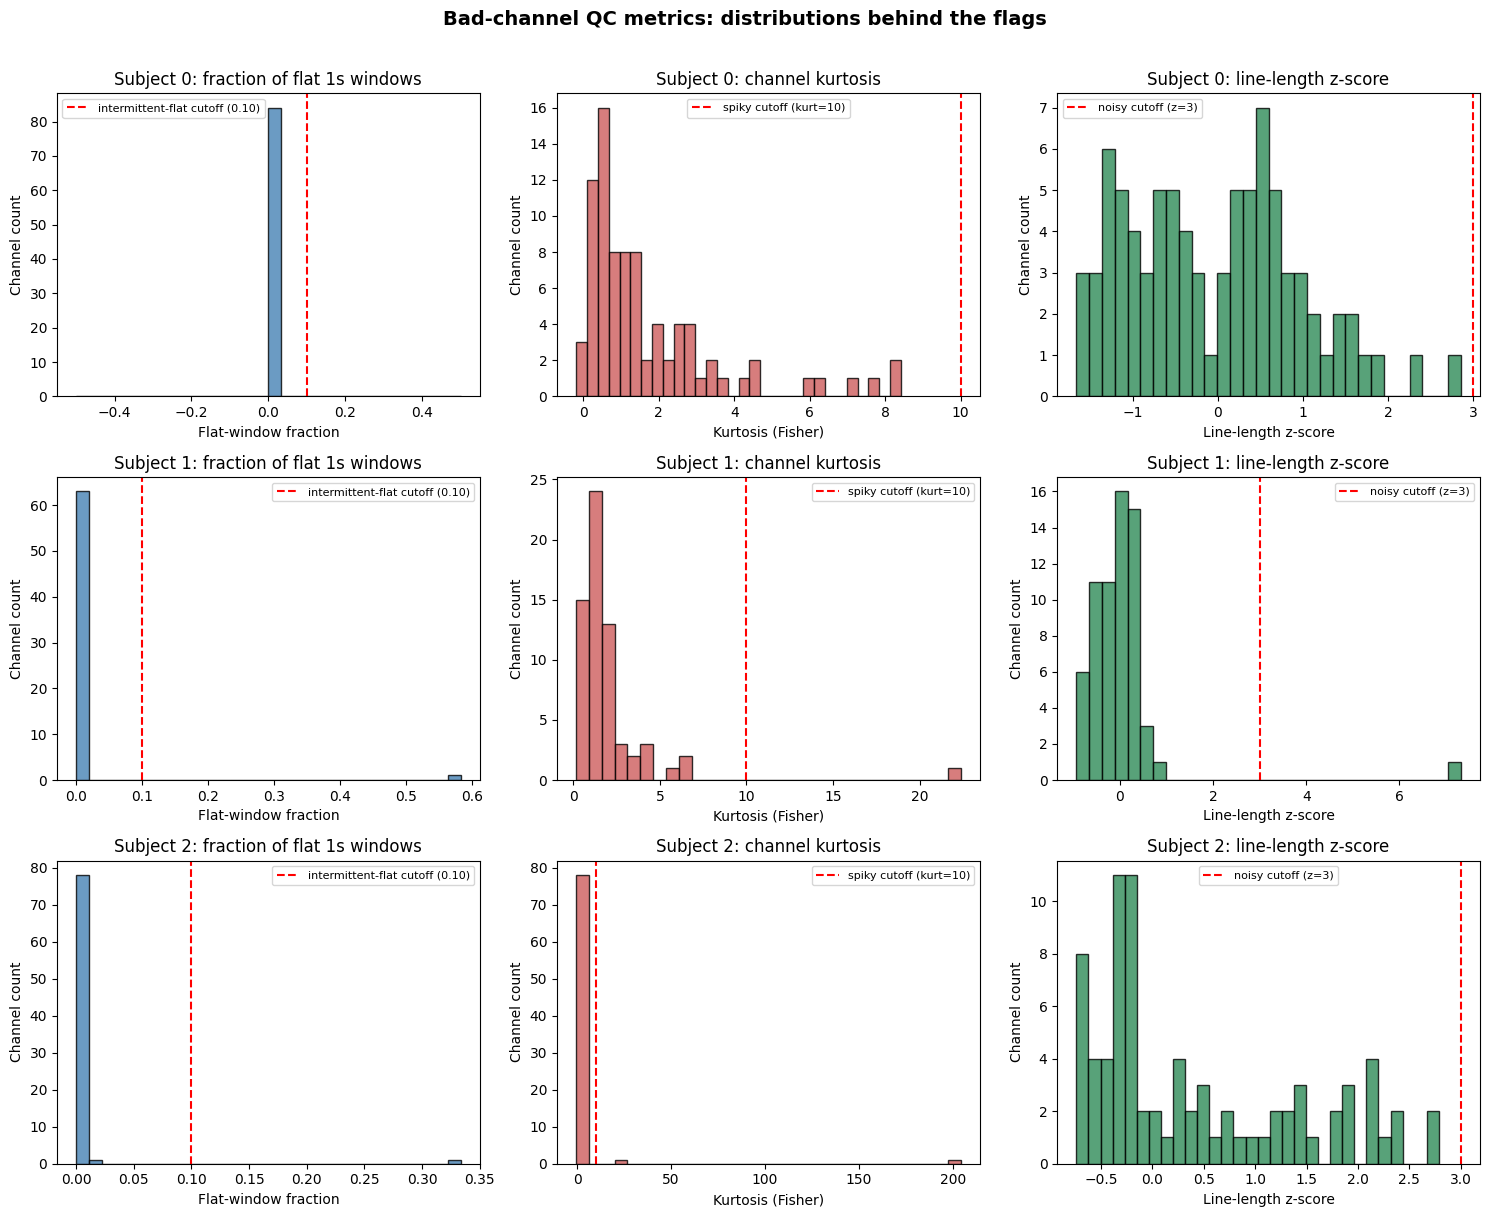

In [8]:
# ── Bad-channel QC: visualize the metrics behind the flags ──────
# The detectors above are threshold rules on continuous per-channel
# metrics. Plotting each metric's distribution — rather than only printing
# which channels got flagged — shows whether the cutoff sits in a natural
# gap or cuts through a continuous spread.

fig, axes = plt.subplots(len(alldat), 3, figsize=(15, 4 * len(alldat)))

for subj in range(len(alldat)):
    metrics = channel_metrics[subj]
    flat_frac = metrics['flat_frac']
    kurt = metrics['kurtosis']
    ll_z = metrics['line_length_z']

    ax_flat, ax_kurt, ax_ll = axes[subj]

    ax_flat.hist(flat_frac, bins=30, color='steelblue', edgecolor='k', alpha=0.8)
    ax_flat.axvline(0.10, color='red', linestyle='--', label='intermittent-flat cutoff (0.10)')
    ax_flat.set_title(f'Subject {subj}: fraction of flat 1s windows')
    ax_flat.set_xlabel('Flat-window fraction'); ax_flat.set_ylabel('Channel count')
    ax_flat.legend(fontsize=8)

    ax_kurt.hist(kurt, bins=30, color='indianred', edgecolor='k', alpha=0.8)
    ax_kurt.axvline(10, color='red', linestyle='--', label='spiky cutoff (kurt=10)')
    ax_kurt.set_title(f'Subject {subj}: channel kurtosis')
    ax_kurt.set_xlabel('Kurtosis (Fisher)'); ax_kurt.set_ylabel('Channel count')
    ax_kurt.legend(fontsize=8)

    ax_ll.hist(ll_z, bins=30, color='seagreen', edgecolor='k', alpha=0.8)
    ax_ll.axvline(3, color='red', linestyle='--', label='noisy cutoff (z=3)')
    ax_ll.set_title(f'Subject {subj}: line-length z-score')
    ax_ll.set_xlabel('Line-length z-score'); ax_ll.set_ylabel('Channel count')
    ax_ll.legend(fontsize=8)

plt.suptitle('Bad-channel QC metrics: distributions behind the flags',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Observations:

Subject 0: every metric sits well clear of its cutoff — this is why subject 0 came back with all 84 channels clean. The line-length panel has one channel nudging close to z=3, but nothing crosses it.

Subject 1: one channel sits way out past the flat-window cutoff (~0.58 vs. cutoff 0.10) and way out past the kurtosis cutoff (~22 vs. cutoff 10) — that's channel 43, flagged for both reasons earlier. A separate single channel sits far out on line-length z (~7 vs. cutoff 3) — that's channel 53, flagged "noisy" only. Everyone else is a tight, well-behaved cluster near zero.

Subject 2: same pattern, but more extreme — one channel's kurtosis is ~204 (that's channels 33/34), so extreme it stretches the whole x-axis and squashes the cutoff line up against the left edge, visually dwarfing the rest of the (otherwise unremarkable) channels.


In all three subjects, "bad channel" isn't just messing around — the cutoffs aren't slicing through a continuous spread of ambiguous channels, they're cleanly separating one or two obviously outlying channels from an otherwise well-behaved majority. Happy with this validation that the thresholds (0.10 / kurt=10 / z=3) work

---

## Signal processing:
*Clean signal and extract features we wanna analyse as the raw voltage carries little; the INFORMATION will be in band power.*

**I. Reject bad channels FIRST** — *before* averaging across channels.




In [9]:
# --- Reject bad channels ---
# Remove flagged channels from V and associated metadata.
# Stores results in `rejected` dict, preserving original channel mapping.

rejected = {}

for subj in range(len(alldat)):
    V = alldat[subj]['V'].astype(np.float32)
    n_ch = V.shape[1]
    bads = bad_channels.get(subj, [])
    goods = sorted(set(range(n_ch)) - set(bads))

    subj_data = {
        'V': V[:, goods],
        'good_idx': np.array(goods),
        'locs': alldat[subj]['locs'][goods],
        'dg': alldat[subj]['dg'],
        't_on': alldat[subj]['t_on'],
        't_off': alldat[subj]['t_off'],
        'stim_id': alldat[subj]['stim_id'],
        'srate': int(alldat[subj]['srate'].item()),
    }

    for key in ['hemisphere', 'lobe', 'gyrus', 'Brodmann_Area']:
        if key in alldat[subj]:
            labels = alldat[subj][key]
            if hasattr(labels, '__len__') and len(labels) == n_ch:
                subj_data[key] = np.array(labels)[goods]

    rejected[subj] = subj_data
    print(f"Subject {subj}: {n_ch} → {len(bads)} rejected → {len(goods)} kept")
    print(f"  Bad: {bads if bads else 'none'}")


Subject 0: 84 → 0 rejected → 84 kept
  Bad: none
Subject 1: 64 → 2 rejected → 62 kept
  Bad: [np.int64(43), np.int64(53)]
Subject 2: 80 → 2 rejected → 78 kept
  Bad: [np.int64(33), np.int64(34)]


**II. Common-average reference (CAR):** subtract the mean across the *remaining* channels

In [10]:
# --- Common-average reference (CAR) ---
# At each timepoint, subtract mean across all remaining good channels.
# Removes shared noise (reference drift, volume-conducted artefact).

cleaned = {}

for subj in range(len(alldat)):
    V = rejected[subj]['V']
    car = V.mean(axis=1, keepdims=True)
    V_car = V - car

    cleaned[subj] = {**rejected[subj], 'V': V_car}

    print(f"Subject {subj}: CAR applied — V shape {V_car.shape}")

    # Calculate noise-reduction metrics
    corr_before = np.corrcoef(V, rowvar=False)
    n_ch = V.shape[1]
    mean_corr_before = (np.sum(corr_before) - np.trace(corr_before)) / (n_ch * (n_ch - 1)) if n_ch > 1 else 0

    corr_after = np.corrcoef(V_car, rowvar=False)
    mean_corr_after = (np.sum(corr_after) - np.trace(corr_after)) / (n_ch * (n_ch - 1)) if n_ch > 1 else 0

    var_before = np.var(V, axis=0).mean()
    var_after = np.var(V_car, axis=0).mean()
    var_reduction = (var_before - var_after) / var_before if var_before > 0 else 0

    print(f"  Mean channel correlation: {mean_corr_before:.4f} -> {mean_corr_after:.4f}")
    print(f"  Average channel variance:  {var_before:.4f} -> {var_after:.4f} ({var_reduction:.2%} reduction)\n")


Subject 0: CAR applied — V shape (610040, 84)
  Mean channel correlation: 0.0676 -> -0.0118
  Average channel variance:  1.0000 -> 0.9213 (7.87% reduction)

Subject 1: CAR applied — V shape (610040, 62)
  Mean channel correlation: 0.1580 -> -0.0157
  Average channel variance:  1.0000 -> 0.8284 (17.16% reduction)

Subject 2: CAR applied — V shape (444840, 78)
  Mean channel correlation: 0.1050 -> -0.0128
  Average channel variance:  1.0000 -> 0.8835 (11.65% reduction)



**IV. Extract broadband** high-frequency amplitude (70–150 Hz) **and beta** (12–20 Hz)

Both features use the same pipeline: band-pass → Hilbert envelope → smooth → z-score.
The helper function `extract_band_amplitude()` encapsulates this, so we call it twice
with different frequency bands.

In [11]:
# ── Extract broadband (high-gamma) and beta amplitude envelopes ─
# Both use the same pipeline defined in extract_band_amplitude().
# Broadband (70–150 Hz): tracks local cortical population firing rate.
# Beta (12–20 Hz): desynchronises (drops) during movement.

broadband = {}
beta = {}

for subj in range(len(alldat)):
    srate = int(cleaned[subj]['srate'])
    V = cleaned[subj]['V']

    broadband[subj] = extract_band_amplitude(V, srate, *BROADBAND_BAND)
    beta[subj]      = extract_band_amplitude(V, srate, *BETA_BAND)

    print(f"Subject {subj}: broadband {broadband[subj].shape}, beta {beta[subj].shape}")


Subject 0: broadband (610040, 84), beta (610040, 84)
Subject 1: broadband (610040, 62), beta (610040, 62)
Subject 2: broadband (444840, 78), beta (444840, 78)


---

## Movement-onset detection
*Find the exact moment each finger actually starts moving, from the GLOVE (not the cue). Why: our whole question is "how early before movement" — with no onset, there's no "before".*


**I.** For each trial, take the cued finger's glove trace

In [12]:
# ── Step I: Segment cued finger glove traces (Single Subject) ────
# For each trial, extract the glove trace for the cued finger
# (stim_id - 1) from -BASELINE_S to +TRIAL_S relative to cue onset.

subj = SUBJ
dg = cleaned[subj]['dg'].astype(np.float32)
srate = int(cleaned[subj]['srate'])
t_on = cleaned[subj]['t_on'].flatten().astype(int)
stim_id = cleaned[subj]['stim_id'].flatten().astype(int)

n_trials = len(t_on)
pre_samples  = int(BASELINE_S * srate)
post_samples = int(TRIAL_S * srate)

segmented_traces = []

for trial_idx in range(n_trials):
    ton = t_on[trial_idx]
    cued_finger = stim_id[trial_idx] - 1  # stim_id is 1-5, cols are 0-4

    start_idx = ton - pre_samples
    end_idx   = ton + post_samples

    if start_idx >= 0 and end_idx <= dg.shape[0]:
        trace = dg[start_idx:end_idx, cued_finger]
    else:
        trace = np.zeros(pre_samples + post_samples)

    segmented_traces.append(trace)

segmented_traces = np.array(segmented_traces)
print(f"Subject {subj} trace matrix shape: {segmented_traces.shape}")


Subject 0 trace matrix shape: (150, 2500)


In [13]:
# ── Steps II & III: Baseline & Onset Detection ───────────────────
# Uses the helper function detect_movement_onset() to find the
# first movement onset in each trial. The function computes a
# per-trial baseline (mean + SD) and searches for the first sample
# exceeding the threshold for a sustained duration.
#
# We store:
#   - onsets_rel_ms: cue-relative latency in ms
#   - thresholds:    the threshold used for each trial (for plotting)
#   - onset_abs_samples: absolute sample index in continuous dg / V

onsets_rel_ms = []
thresholds = []

for trace in segmented_traces:
    onset, thresh = detect_movement_onset(trace, pre_samples)
    onsets_rel_ms.append(onset)
    thresholds.append(thresh)

onsets_rel_ms = np.array(onsets_rel_ms, dtype=float)

# Compute absolute onset sample indices for epoching
onset_abs_samples = np.array([
    t_on[i] + val if not np.isnan(val) else np.nan
    for i, val in enumerate(onsets_rel_ms)
], dtype=float)

# Summary
valid_onsets = np.sum(~np.isnan(onsets_rel_ms))
print(f"Detected onsets in {valid_onsets} / {n_trials} trials.")
print(f"Average latency from cue: {np.nanmean(onsets_rel_ms):.1f} ms")


Detected onsets in 149 / 150 trials.
Average latency from cue: 720.8 ms


In [14]:
# ── Physiological Latency Filtering ─────────────────────────────
# Filter out anticipatory movements (< 150 ms) and non-responses (> 2000 ms)
MIN_LATENCY_MS = 150
MAX_LATENCY_MS = 2000

# Identify invalid trial indices
early_trials = np.where(onsets_rel_ms < MIN_LATENCY_MS)[0]
late_trials  = np.where(onsets_rel_ms > MAX_LATENCY_MS)[0]

print(f"Anticipatory/early trials (< {MIN_LATENCY_MS} ms): {list(early_trials)}")
print(f"Late/unresponsive trials (> {MAX_LATENCY_MS} ms): {list(late_trials)}")

# Invalidate out-of-bounds onsets
invalid_mask = (onsets_rel_ms < MIN_LATENCY_MS) | (onsets_rel_ms > MAX_LATENCY_MS)
onsets_rel_ms[invalid_mask] = np.nan

# Update absolute sample indices
onset_abs_samples[invalid_mask] = np.nan

# Updated summary
clean_onsets = np.sum(~np.isnan(onsets_rel_ms))
print(f"\nClean valid onsets remaining: {clean_onsets} / {n_trials}")
print(f"Adjusted average latency: {np.nanmean(onsets_rel_ms):.1f} ms")

Anticipatory/early trials (< 150 ms): [np.int64(3), np.int64(6), np.int64(15), np.int64(20), np.int64(37), np.int64(39), np.int64(40), np.int64(47), np.int64(71), np.int64(74), np.int64(75), np.int64(80), np.int64(108), np.int64(117), np.int64(131), np.int64(137)]
Late/unresponsive trials (> 2000 ms): []

Clean valid onsets remaining: 133 / 150
Adjusted average latency: 800.0 ms


### Figure 1 — Onset validation
Overlay the saved baseline threshold and the detected onset on a sample of cued-finger glove traces. This proves a per-trial **t = 0** exists from the glove.


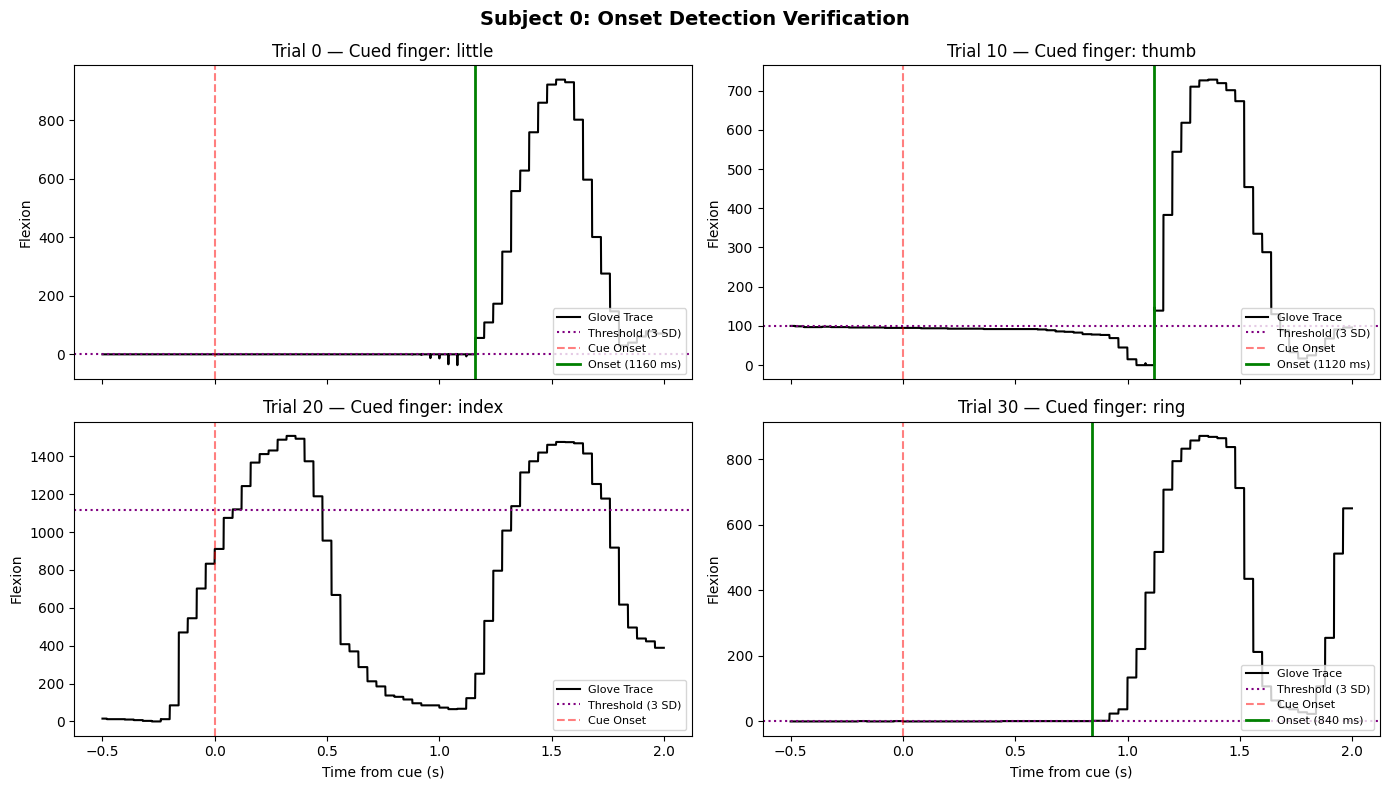

In [15]:
# ── Step IV: Onset Validation Plot ────────────────────────────────
# Plots a selection of trials, overlaying the saved threshold
# and detected onset time. No recalculations needed — we use
# the thresholds[] and onsets_rel_ms[] from the detection step.

trials_to_plot = [0, 10, 20, 30]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()
t_axis = np.arange(-pre_samples, post_samples) / srate

for idx, trial_num in enumerate(trials_to_plot):
    trace = segmented_traces[trial_num]
    ax = axes[idx]

    ax.plot(t_axis, trace, color='black', label='Glove Trace', linewidth=1.5)
    ax.axhline(thresholds[trial_num], color='purple', linestyle=':',
              label=f'Threshold ({ONSET_SD_MULT:.0f} SD)', linewidth=1.5)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Cue Onset')

    # Overlay detected onset
    onset_ms = onsets_rel_ms[trial_num]
    if not np.isnan(onset_ms):
        onset_s = onset_ms / 1000.0
        ax.axvline(onset_s, color='green', linestyle='-',
                   label=f'Onset ({onset_ms:.0f} ms)', linewidth=2)

    f_name = FINGER_NAMES[cleaned[subj]['stim_id'][trial_num] - 1]
    ax.set_title(f"Trial {trial_num} — Cued finger: {f_name}")
    ax.set_ylabel("Flexion")
    if idx >= 2:
        ax.set_xlabel("Time from cue (s)")
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle(f"Subject {subj}: Onset Detection Verification",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Figure 1b — Nonparametric threshold cross-check
`detect_movement_onset()`'s "mean + 3 SD" threshold assumes the pre-cue baseline noise is Gaussian. To test that assumption without throwing away the (necessary) per-trial normalization, we z-score each trial's own baseline first — same as the parametric method — then pool the z-scored values across all 150 trials and ask what the *empirical* 99.865th percentile is (the percentile a true Gaussian would place at exactly z=3). If the empirical value is close to 3, the Gaussian assumption is fine; if it's notably higher, real baseline noise has heavier tails than Gaussian and the parametric threshold is a bit too lenient.


Subject 0: nonparametric threshold cross-check
  Gaussian would place the 99.865th percentile at z = 3.000
  Empirical 99.865th percentile of real (per-trial z-scored) baseline noise: z = 3.601

  Valid onsets — parametric: 133/150, nonparametric: 147/150
  Trials with both methods valid: 132
  Mean shift (nonparametric - parametric): +71.52 ms
  Median shift: +0.00 ms
  Max absolute shift: 840.0 ms


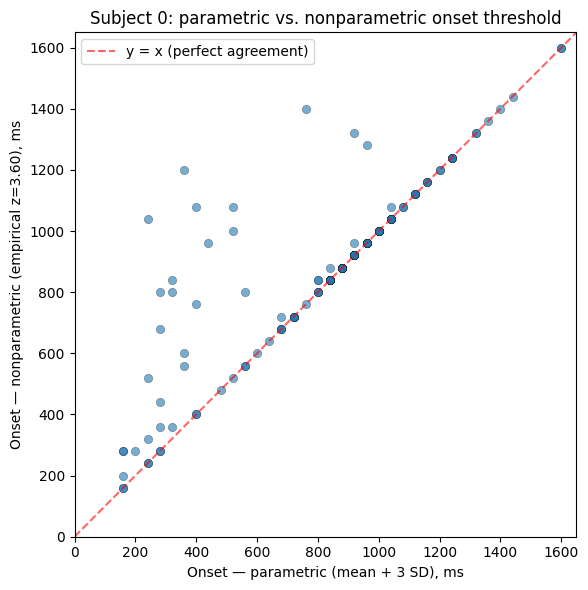

In [16]:
# ── Cross-check: nonparametric (percentile-based) onset threshold ──
# detect_movement_onset() assumes the pre-cue baseline is Gaussian, so
# "mean + ONSET_SD_MULT*SD" is only a meaningful "how unusual is this"
# threshold if that assumption holds. A first attempt at testing this by
# pooling RAW baseline magnitudes across trials badly overcorrects: per-trial
# baseline SD varies by ~2 orders of magnitude across these 150 trials
# (most trials sit near SD~1, but a handful of noisy trials reach SD>100),
# so a pooled-raw threshold gets dominated by those few noisy trials and
# becomes far too conservative for every calm trial. Per-trial normalization
# (as detect_movement_onset() already does) is therefore not just a
# convenience — it's necessary given how heterogeneous baseline noise is
# trial to trial. So here we z-score EACH TRIAL by its own baseline mean/SD
# first (keeping that per-trial adaptivity), and only pool AFTER
# normalizing — this isolates whether the *shape* of the noise is Gaussian,
# without re-introducing the cross-trial scale mismatch.

from scipy.stats import norm

EQUIV_PERCENTILE = norm.cdf(ONSET_SD_MULT) * 100  # 3 SD -> 99.865th percentile

per_trial_mu = np.array([np.mean(segmented_traces[t, :pre_samples]) for t in range(n_trials)])
per_trial_sd = np.array([np.std(segmented_traces[t, :pre_samples]) for t in range(n_trials)])
per_trial_sd_safe = np.where(per_trial_sd == 0, 1.0, per_trial_sd)

# Pool z-scored baseline samples across all trials
z_pool = np.concatenate([
    (segmented_traces[t, :pre_samples] - per_trial_mu[t]) / per_trial_sd_safe[t]
    for t in range(n_trials)
])
empirical_z_threshold = np.percentile(z_pool, EQUIV_PERCENTILE)

print(f"Subject {subj}: nonparametric threshold cross-check")
print(f"  Gaussian would place the {EQUIV_PERCENTILE:.3f}th percentile at z = {ONSET_SD_MULT:.3f}")
print(f"  Empirical {EQUIV_PERCENTILE:.3f}th percentile of real (per-trial z-scored) baseline noise: z = {empirical_z_threshold:.3f}")


def detect_movement_onset_percentile(trace, pre_samples, z_threshold, sustained_ms=ONSET_SUSTAIN_MS):
    """
    Nonparametric counterpart to detect_movement_onset(): still normalizes
    each trial by its own baseline mean/SD (same as the parametric method),
    but thresholds against an EMPIRICALLY estimated z-value instead of
    assuming the Gaussian value of exactly `sd_multiplier`.
    """
    mu = np.mean(trace[:pre_samples])
    sd = np.std(trace[:pre_samples])
    sd = sd if sd > 0 else 1.0
    post_cue_z = (trace[pre_samples:] - mu) / sd

    for i in range(len(post_cue_z) - sustained_ms):
        if np.all(post_cue_z[i : i + sustained_ms] > z_threshold):
            return i

    return np.nan


onsets_rel_ms_pctile = np.array([
    detect_movement_onset_percentile(trace, pre_samples, empirical_z_threshold)
    for trace in segmented_traces
], dtype=float)

# ── Compare to the parametric (mean + 3 SD) onsets ──
both_valid = ~np.isnan(onsets_rel_ms) & ~np.isnan(onsets_rel_ms_pctile)
diff = onsets_rel_ms_pctile[both_valid] - onsets_rel_ms[both_valid]

print(f"\n  Valid onsets — parametric: {np.sum(~np.isnan(onsets_rel_ms))}/{n_trials}, "
      f"nonparametric: {np.sum(~np.isnan(onsets_rel_ms_pctile))}/{n_trials}")
print(f"  Trials with both methods valid: {both_valid.sum()}")
print(f"  Mean shift (nonparametric - parametric): {np.mean(diff):+.2f} ms")
print(f"  Median shift: {np.median(diff):+.2f} ms")
print(f"  Max absolute shift: {np.max(np.abs(diff)):.1f} ms")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(onsets_rel_ms[both_valid], onsets_rel_ms_pctile[both_valid],
           alpha=0.6, edgecolor='k', linewidth=0.3)
lims = [0, max(onsets_rel_ms[both_valid].max(), onsets_rel_ms_pctile[both_valid].max()) + 50]
ax.plot(lims, lims, 'r--', alpha=0.6, label='y = x (perfect agreement)')
ax.set_xlabel(f'Onset — parametric (mean + {ONSET_SD_MULT:.0f} SD), ms')
ax.set_ylabel(f'Onset — nonparametric (empirical z={empirical_z_threshold:.2f}), ms')
ax.set_title(f'Subject {subj}: parametric vs. nonparametric onset threshold')
ax.legend()
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.show()


**VI.** Derive the **glove-observed finger** per trial (largest normalized flexion) and keep it **alongside** the cued `stim_id` — never overwrite. Attach a per-trial **dominance margin** (top finger minus runner-up) so trials can be sorted from clean single-finger to coupled near-ties.

In [17]:
# --- Glove-Observed Finger Labeling (normalized) ---
# Which finger actually moved most in the post-cue window?
# The five glove sensors have different scales/offsets, so "largest flexion"
# would partly just mean "largest sensor". We first put every finger on a
# common scale (its own SD over the whole recording) BEFORE comparing across
# fingers. We also record a per-trial DOMINANCE MARGIN = top finger's peak
# minus the runner-up's. Big margin = clean single-finger trial; small margin
# = a coupled near-tie. This lets us sort trials rather than relabel them.

# Uses FINGER_NAMES from global config

dg = cleaned[subj]['dg'].astype(np.float32)
srate = cleaned[subj]['srate']
t_on = cleaned[subj]['t_on'].flatten().astype(int)
stim_id = cleaned[subj]['stim_id'].flatten().astype(int)

pre_samples = int(0.5 * srate)
post_samples = int(2.0 * srate)

# Common scale across sensors: each finger by its own SD over the full recording.
finger_scale = dg.std(axis=0)
finger_scale[finger_scale == 0] = 1.0  # guard against a dead glove channel
dg_norm = dg / finger_scale            # each finger now in comparable units

glove_observed_fingers = []
dominance_margins = []
finger_max_flexions = []

for trial_idx in range(n_trials):
    ton = t_on[trial_idx]

    # 1. Baseline mean per finger (normalized units)
    baseline_means = np.mean(dg_norm[ton - pre_samples : ton, :], axis=0)

    # 2. Baseline-corrected peak flexion per finger in the post-cue window
    post_cue = dg_norm[ton : ton + post_samples, :] - baseline_means
    max_flexions = np.max(post_cue, axis=0)

    # 3. Winner and margin over the runner-up
    order = np.argsort(max_flexions)[::-1]  # descending
    observed_finger = int(order[0]) + 1     # 1-based label
    margin = float(max_flexions[order[0]] - max_flexions[order[1]])

    glove_observed_fingers.append(observed_finger)
    dominance_margins.append(margin)
    finger_max_flexions.append(max_flexions)

glove_observed_fingers = np.array(glove_observed_fingers)
dominance_margins = np.array(dominance_margins)
finger_max_flexions = np.array(finger_max_flexions)  # (n_trials, 5)

# Where does the normalized glove disagree with the cue?
disagreements = np.where(glove_observed_fingers != stim_id)[0]

# Coupled near-ties: margin too small to trust as a confident relabel
# (cf. trial 137, margin=0.02) vs. a clear winner (cf. trial 125, margin=2.55,
# well inside the normal IQR). Used below to build final_label.
low_confidence = dominance_margins < LOW_MARGIN_THRESHOLD

print(f"Subject {subj}:")
print(f"  Disagreements between cue and observed movement: {len(disagreements)} / {n_trials} trials")
print(f"  Dominance margin (normalized units): "
      f"median {np.median(dominance_margins):.2f}, "
      f"IQR [{np.quantile(dominance_margins, 0.25):.2f}, {np.quantile(dominance_margins, 0.75):.2f}]")
if len(disagreements) > 0:
    print(f"  Disagreement trial indices: {disagreements.tolist()}")
    for trial_idx in disagreements[:5]:
        cued = FINGER_NAMES[stim_id[trial_idx] - 1]
        actual = FINGER_NAMES[glove_observed_fingers[trial_idx] - 1]
        print(f"    Trial {trial_idx:3d}: Cued {cued:6s} | Moved {actual:6s} | margin {dominance_margins[trial_idx]:.2f}")
print(f"  Low-confidence (margin < {LOW_MARGIN_THRESHOLD}) trials: {int(low_confidence.sum())} / {n_trials}")


Subject 0:
  Disagreements between cue and observed movement: 2 / 150 trials
  Dominance margin (normalized units): median 4.38, IQR [3.73, 4.96]
  Disagreement trial indices: [125, 137]
    Trial 125: Cued middle | Moved ring   | margin 2.55
    Trial 137: Cued little | Moved index  | margin 0.02
  Low-confidence (margin < 0.1) trials: 2 / 150


In [18]:
# --- Trial label table: keep BOTH cued and observed, never overwrite ---
# cued_finger comes from stim_id, observed_finger from the (normalized) glove.
# We keep them side by side and attach the dominance margin so trials can be
# SORTED by how clean/single-finger they are — clean single-finger trials for
# decoding, coupled near-ties as Q4 evidence — instead of destroying
# information by relabeling. onset columns come from the detector above.

import pandas as pd

cued_finger = cleaned[subj]['stim_id'].flatten().astype(int)

trials_df = pd.DataFrame({
    'trial': np.arange(n_trials),
    'cued_finger': cued_finger,
    'observed_finger': glove_observed_fingers,
    'agree': cued_finger == glove_observed_fingers,
    'margin': dominance_margins,
    'onset_rel_ms': onsets_rel_ms,
    'onset_abs_sample': onset_abs_samples,
})
trials_df['cued_name'] = [FINGER_NAMES[f - 1] for f in trials_df['cued_finger']]
trials_df['observed_name'] = [FINGER_NAMES[f - 1] for f in trials_df['observed_finger']]

# Labeling decision: we're predicting what physically moved,
# so observed_finger — not cued_finger — is the training label. A
# mislabeled trial where cued != observed would corrupt training if we used
# the cue instead. cued_finger stays untouched as a separate column.
#
# Exception: a near-zero margin (cf. trial 137, margin=0.02) is a coupled
# near-tie, not a confident read of what moved — relabeling it would just
# swap one low-confidence guess for another. Those trials get final_label
# set to NaN and are excluded via include_in_decoding, rather than silently
# relabeled. A trial with a real margin (cf. trial 125, margin=2.55, well
# inside the normal IQR) is a confident relabel with no such caveat.
trials_df['final_label'] = trials_df['observed_finger']
trials_df.loc[trials_df['margin'] < LOW_MARGIN_THRESHOLD, 'final_label'] = np.nan
trials_df['low_confidence']      = trials_df['margin'] < LOW_MARGIN_THRESHOLD
trials_df['include_in_decoding'] = trials_df['final_label'].notna() & trials_df['onset_abs_sample'].notna()

n_agree = int(trials_df['agree'].sum())
print(f"Subject {subj}: {len(trials_df)} trials — "
      f"{n_agree} agree / {len(trials_df) - n_agree} disagree "
      f"(cued vs. glove-observed kept separate, nothing overwritten)")

cols = ['trial', 'cued_name', 'observed_name', 'agree', 'margin', 'onset_rel_ms']
print("\nCleanest single-finger trials (largest margin):")
print(trials_df.sort_values('margin', ascending=False).head()[cols].to_string(index=False))
print("\nMost coupled / near-tie trials (smallest margin):")
print(trials_df.sort_values('margin').head()[cols].to_string(index=False))

# Visible check of the labeling decision against the two trials discussed:
if 125 in trials_df['trial'].values and 137 in trials_df['trial'].values:
    row_125 = trials_df.loc[trials_df['trial'] == 125].iloc[0]
    row_137 = trials_df.loc[trials_df['trial'] == 137].iloc[0]
    label_125 = FINGER_NAMES[int(row_125['final_label']) - 1] if not np.isnan(row_125['final_label']) else 'NaN'
    print(f"\nLabeling decision check — "
          f"trial 125 (margin={row_125['margin']:.2f}): final_label={label_125} (confident relabel to observed); "
          f"trial 137 (margin={row_137['margin']:.2f}): include_in_decoding={bool(row_137['include_in_decoding'])} "
          f"(coupled near-tie, excluded rather than relabeled)")


Subject 0: 150 trials — 148 agree / 2 disagree (cued vs. glove-observed kept separate, nothing overwritten)

Cleanest single-finger trials (largest margin):
 trial cued_name observed_name  agree   margin  onset_rel_ms
     3     thumb         thumb   True 6.991868           NaN
     7      ring          ring   True 6.512508         520.0
     8     thumb         thumb   True 6.354389         960.0
    13      ring          ring   True 6.162563         480.0
     6    middle        middle   True 5.957122           NaN

Most coupled / near-tie trials (smallest margin):
 trial cued_name observed_name  agree   margin  onset_rel_ms
    99     index         index   True 0.015425         600.0
   137    little         index  False 0.017247           NaN
   106      ring          ring   True 0.388668         360.0
    36      ring          ring   True 0.725146         280.0
   122     thumb         thumb   True 0.908270        1600.0

Labeling decision check — trial 125 (margin=2.55): final_la

### Figure 1c — Onset latency by finger
Box + violin plot of `onset_rel_ms` grouped by cued finger — a bivariate view asking whether some fingers are simply slower or faster to move than others, independent of the neural question.


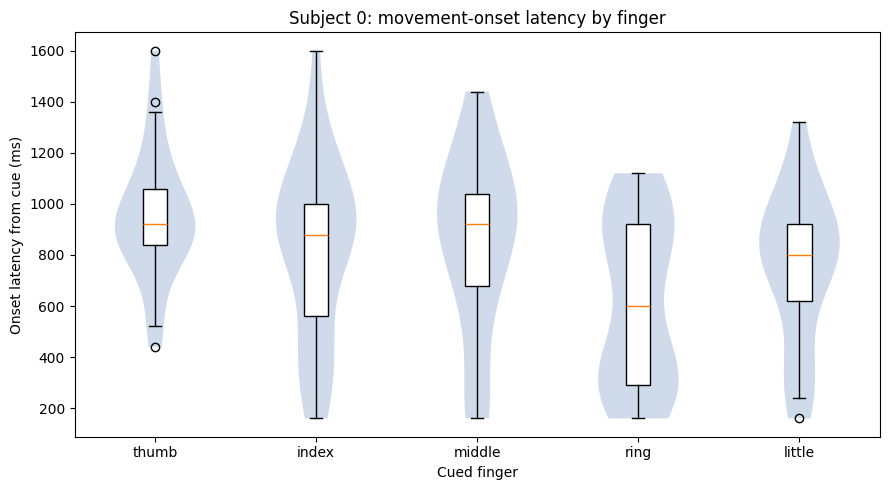

Subject 0: onset latency by finger
  thumb   : n= 28, median=920 ms, IQR=[840, 1060] ms
  index   : n= 27, median=880 ms, IQR=[560, 1000] ms
  middle  : n= 25, median=920 ms, IQR=[680, 1040] ms
  ring    : n= 26, median=600 ms, IQR=[290, 920] ms
  little  : n= 27, median=800 ms, IQR=[620, 920] ms


In [19]:
# ── Onset latency by finger (box + violin) ───────────────────────
# Bivariate view: does movement-onset latency differ by which finger was
# cued? The box shows median/IQR/outliers per finger; the violin overlay
# shows the full shape of each finger's latency distribution. Uses
# trials_df's onset_rel_ms, which already reflects both the onset detector
# and the physiological latency filter applied above.

fig, ax = plt.subplots(figsize=(9, 5))

finger_order = FINGER_NAMES
latency_by_finger = [
    trials_df.loc[trials_df['cued_name'] == f, 'onset_rel_ms'].dropna().values
    for f in finger_order
]
positions = range(1, len(finger_order) + 1)

parts = ax.violinplot(latency_by_finger, positions=positions,
                       showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('lightsteelblue')
    pc.set_alpha(0.6)

box = ax.boxplot(latency_by_finger, positions=positions, widths=0.15,
                  patch_artist=True, showfliers=True)
for patch in box['boxes']:
    patch.set_facecolor('white')

ax.set_xticks(list(positions))
ax.set_xticklabels(finger_order)
ax.set_xlabel('Cued finger')
ax.set_ylabel('Onset latency from cue (ms)')
ax.set_title(f'Subject {subj}: movement-onset latency by finger')

plt.tight_layout()
plt.show()

print(f"Subject {subj}: onset latency by finger")
for f, latencies in zip(finger_order, latency_by_finger):
    if len(latencies) > 0:
        print(f"  {f:8s}: n={len(latencies):3d}, median={np.median(latencies):.0f} ms, "
              f"IQR=[{np.percentile(latencies, 25):.0f}, {np.percentile(latencies, 75):.0f}] ms")
    else:
        print(f"  {f:8s}: n=0 (no valid onsets)")


Observations: the ring finger clearly stands out — median onset latency ~600ms vs ~800-920ms for the other four fingers. Its box (IQR ~290-920ms) is also shifted lower and wider than the others, and its lower quartile sits right near the 150ms floor from our anticipatory-movement filter the ring finger is anatomically the most tendon-coupled to its neighbours (middle, little) — a finger that's less independently controlled would plausibly show more variable, sometimes-earlier "crossings" of the onset threshold, possibly because a co-contraction from an adjacent finger's movement helps trip the detector sooner. Worth checking in our writeup whether this apparent "ring finger moves faster" pattern is a genuine reaction-time effect, or a side effect of the same biomechanical coupling...

### Generalizing to all 3 subjects
`compute_trials_df(subj)` wraps the onset-detection + glove-observed-labeling pipeline above into one function per subject, and codes the labeling decision discussed earlier: `final_label` = `observed_finger` (decode what physically moved), with low-margin coupled near-ties flagged via `low_confidence` and excluded from `include_in_decoding` rather than confidently relabeled. `cued_finger` stays untouched. Run once per subject into `trials_df_all` — never pooled.


In [20]:
# ── Generalize onset detection + labeling to all 3 subjects ──────
# Everything above (Figures 1, 1b, 1c) ran on subject 0 only, for a clear
# single-subject walkthrough. Module 5 (decoding) needs a validated
# trials_df for every subject — analysed separately, never pooled, per the
# guardrail that subjects have different channel counts and consistency
# across the 3 is itself the result. compute_trials_df() wraps the exact
# same pipeline used above (segment -> detect onset -> physiological
# latency filter -> glove-observed labeling -> trial table) into one
# function parameterized by subj, so it can be re-run per subject without
# duplicating the logic.
#
# It also finally codes the labeling decision discussed earlier: observed_finger becomes final_label — the target for decoding,
# since we're predicting what physically moved — EXCEPT when the dominance
# margin is below LOW_MARGIN_THRESHOLD, in which case the trial is a
# coupled near-tie (like trial 137 above, margin=0.02) and gets flagged
# low_confidence + excluded via include_in_decoding, rather than being
# confidently relabeled off a near-zero margin. cued_finger is untouched.

def compute_trials_df(subj, low_margin_threshold=LOW_MARGIN_THRESHOLD,
                       min_latency_ms=MIN_LATENCY_MS, max_latency_ms=MAX_LATENCY_MS):
    """
    Run the onset-detection + glove-observed-labeling pipeline for one
    subject and return a trials_df identical in structure to the subject-0
    walkthrough above (plus final_label / low_confidence /
    include_in_decoding). Reuses detect_movement_onset() — nothing here
    re-derives the signal processing, only makes it callable per subject.
    """
    dg = cleaned[subj]['dg'].astype(np.float32)
    srate = int(cleaned[subj]['srate'])
    t_on = cleaned[subj]['t_on'].flatten().astype(int)
    stim_id = cleaned[subj]['stim_id'].flatten().astype(int)
    n_trials = len(t_on)
    pre_samples = int(BASELINE_S * srate)
    post_samples = int(TRIAL_S * srate)

    # Step I: segment cued-finger glove traces
    segmented_traces = []
    for trial_idx in range(n_trials):
        ton = t_on[trial_idx]
        cued_f = stim_id[trial_idx] - 1
        start_idx, end_idx = ton - pre_samples, ton + post_samples
        if start_idx >= 0 and end_idx <= dg.shape[0]:
            trace = dg[start_idx:end_idx, cued_f]
        else:
            trace = np.zeros(pre_samples + post_samples)
        segmented_traces.append(trace)
    segmented_traces = np.array(segmented_traces)

    # Steps II & III: baseline + onset detection
    onsets_rel_ms, thresholds = [], []
    for trace in segmented_traces:
        onset, thresh = detect_movement_onset(trace, pre_samples)
        onsets_rel_ms.append(onset)
        thresholds.append(thresh)
    onsets_rel_ms = np.array(onsets_rel_ms, dtype=float)
    onset_abs_samples = np.array([
        t_on[i] + val if not np.isnan(val) else np.nan
        for i, val in enumerate(onsets_rel_ms)
    ], dtype=float)

    # Physiological latency filtering
    invalid_mask = (onsets_rel_ms < min_latency_ms) | (onsets_rel_ms > max_latency_ms)
    onsets_rel_ms[invalid_mask] = np.nan
    onset_abs_samples[invalid_mask] = np.nan

    # Glove-observed finger labeling (normalized)
    finger_scale = dg.std(axis=0)
    finger_scale[finger_scale == 0] = 1.0
    dg_norm = dg / finger_scale

    glove_observed_fingers, dominance_margins = [], []
    for trial_idx in range(n_trials):
        ton = t_on[trial_idx]
        baseline_means = np.mean(dg_norm[ton - pre_samples:ton, :], axis=0)
        post_cue = dg_norm[ton:ton + post_samples, :] - baseline_means
        max_flexions = np.max(post_cue, axis=0)
        order = np.argsort(max_flexions)[::-1]
        glove_observed_fingers.append(int(order[0]) + 1)
        dominance_margins.append(float(max_flexions[order[0]] - max_flexions[order[1]]))
    glove_observed_fingers = np.array(glove_observed_fingers)
    dominance_margins = np.array(dominance_margins)
    cued_finger = stim_id

    # Trial label table
    trials_df = pd.DataFrame({
        'trial': np.arange(n_trials),
        'cued_finger': cued_finger,
        'observed_finger': glove_observed_fingers,
        'agree': cued_finger == glove_observed_fingers,
        'margin': dominance_margins,
        'onset_rel_ms': onsets_rel_ms,
        'onset_abs_sample': onset_abs_samples,
    })
    trials_df['cued_name'] = [FINGER_NAMES[f - 1] for f in trials_df['cued_finger']]
    trials_df['observed_name'] = [FINGER_NAMES[f - 1] for f in trials_df['observed_finger']]

    # Labeling decision (Eren's rule): observed_finger is the training
    # label; near-zero-margin trials are flagged and excluded, not relabeled.
    trials_df['final_label'] = trials_df['observed_finger']
    trials_df.loc[trials_df['margin'] < low_margin_threshold, 'final_label'] = np.nan
    trials_df['low_confidence'] = trials_df['margin'] < low_margin_threshold
    trials_df['include_in_decoding'] = trials_df['final_label'].notna() & trials_df['onset_abs_sample'].notna()

    n_agree = int(trials_df['agree'].sum())
    print(f"Subject {subj}: {n_trials} trials — {n_agree} agree / {n_trials - n_agree} disagree, "
          f"{int(trials_df['low_confidence'].sum())} low-confidence (margin < {low_margin_threshold}), "
          f"{int(trials_df['include_in_decoding'].sum())} usable for decoding")

    return trials_df


trials_df_all = {s: compute_trials_df(s) for s in range(len(alldat))}


Subject 0: 150 trials — 148 agree / 2 disagree, 2 low-confidence (margin < 0.1), 132 usable for decoding
Subject 1: 150 trials — 145 agree / 5 disagree, 0 low-confidence (margin < 0.1), 122 usable for decoding
Subject 2: 110 trials — 62 agree / 48 disagree, 20 low-confidence (margin < 0.1), 65 usable for decoding


## Feature EDA

### Figure 2 — Labeling decision: cued vs. observed
`trials_df` keeps the cued label and the glove-observed label side by side with a per-trial dominance `margin` (nothing is overwritten). Left: the cued-vs-observed structure — off-diagonal cells are trials where the dominant glove flexion was not the cued finger. Right: the dominance-margin distribution, split by whether the two labels agree. Small margins are coupled near-ties; large margins are clean single-finger trials.


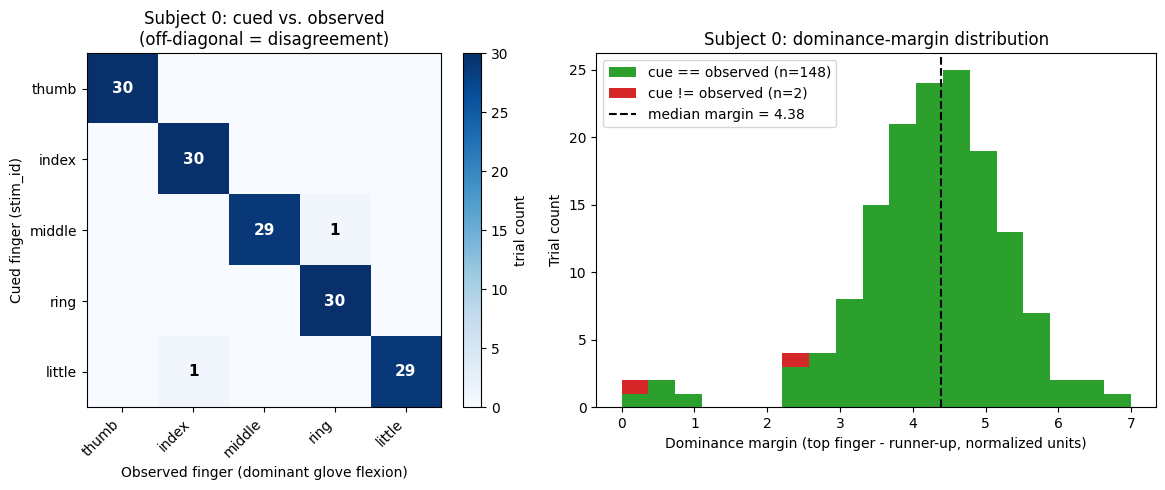

In [21]:
# Figure 2 — Labeling decision: cued vs. observed (from trials_df)
# Descriptive only: cued-vs-observed count structure + dominance-margin
# distribution. Uses the trials_df built above; nothing is recomputed or
# relabeled ("keep both, sort by margin, never overwrite" stays as-is).

fig, (ax_conf, ax_marg) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: cued (rows) vs observed (cols) count matrix ---
conf = np.zeros((N_FINGERS, N_FINGERS), dtype=int)
for cued, obs in zip(trials_df['cued_finger'], trials_df['observed_finger']):
    conf[cued - 1, obs - 1] += 1

im = ax_conf.imshow(conf, cmap='Blues')
ax_conf.set_xticks(range(N_FINGERS)); ax_conf.set_xticklabels(FINGER_NAMES, rotation=45, ha='right')
ax_conf.set_yticks(range(N_FINGERS)); ax_conf.set_yticklabels(FINGER_NAMES)
ax_conf.set_xlabel('Observed finger (dominant glove flexion)')
ax_conf.set_ylabel('Cued finger (stim_id)')
ax_conf.set_title(f'Subject {subj}: cued vs. observed\n(off-diagonal = disagreement)')
for i in range(N_FINGERS):
    for j in range(N_FINGERS):
        if conf[i, j] > 0:
            ax_conf.text(j, i, conf[i, j], ha='center', va='center',
                         color='white' if conf[i, j] > conf.max() / 2 else 'black',
                         fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax_conf, label='trial count', fraction=0.046, pad=0.04)

# --- Right: dominance-margin distribution, split by agreement ---
agree_m = trials_df.loc[trials_df['agree'], 'margin']
disagree_m = trials_df.loc[~trials_df['agree'], 'margin']
bins = np.linspace(0, float(trials_df['margin'].max()), 20)
ax_marg.hist([agree_m, disagree_m], bins=bins, stacked=True,
             color=['tab:green', 'tab:red'],
             label=[f'cue == observed (n={len(agree_m)})',
                    f'cue != observed (n={len(disagree_m)})'])
ax_marg.axvline(float(trials_df['margin'].median()), color='k', linestyle='--',
                label=f"median margin = {trials_df['margin'].median():.2f}")
ax_marg.set_xlabel('Dominance margin (top finger - runner-up, normalized units)')
ax_marg.set_ylabel('Trial count')
ax_marg.set_title(f'Subject {subj}: dominance-margin distribution')
ax_marg.legend()

plt.tight_layout()
plt.show()


### Figure 3 — Glove coupling matrix
5x5 Pearson correlation between the glove sensors during active movement windows (rest periods wash coupling out, so we restrict to movement). Point estimate only. Ring-middle and ring-little are highlighted: they are the biomechanical premise for the ring-coupling question.


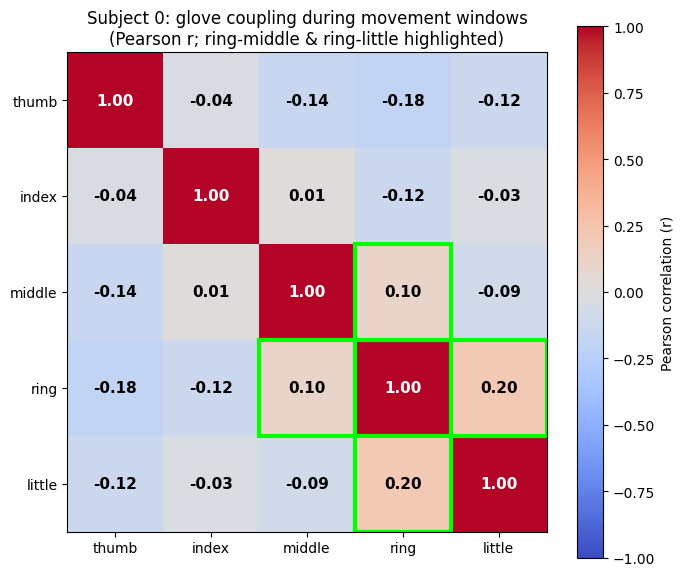

Subject 0: finger-coupling point estimates (Pearson r over movement windows)
-------------------------------------------------------
  thumb    vs index   : r = -0.039
  thumb    vs middle  : r = -0.142
  thumb    vs ring    : r = -0.180
  thumb    vs little  : r = -0.123
  index    vs middle  : r = +0.012
  index    vs ring    : r = -0.118
  index    vs little  : r = -0.026
  middle   vs ring    : r = +0.102
  middle   vs little  : r = -0.090
  ring     vs little  : r = +0.204


In [22]:
# Figure 3 — Glove coupling matrix (point estimate only)
# Pearson correlation between the 5 glove sensors during active-movement windows
# only (rest periods wash the coupling out). Ring<->middle and ring<->little are
# highlighted as the biomechanical premise for the ring-coupling question.

subj = SUBJ
srate = int(cleaned[subj]['srate'])
dg = cleaned[subj]['dg']

post_samples = int(1.5 * srate)  # 1.5 s of active movement per trial
move_segments = []
for onset_sample in onset_abs_samples:
    if not np.isnan(onset_sample):
        m_start = int(onset_sample)
        m_end = int(onset_sample + post_samples)
        if m_end <= dg.shape[0]:
            move_segments.append(dg[m_start:m_end, :])

move_data = np.concatenate(move_segments, axis=0)  # (N_samples, 5)
glove_corr = np.corrcoef(move_data, rowvar=False)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(glove_corr, cmap='coolwarm', vmin=-1.0, vmax=1.0)
ax.set_xticks(range(5)); ax.set_xticklabels(FINGER_NAMES)
ax.set_yticks(range(5)); ax.set_yticklabels(FINGER_NAMES)
ax.set_title(f'Subject {subj}: glove coupling during movement windows\n'
             '(Pearson r; ring-middle & ring-little highlighted)')

for i in range(5):
    for j in range(5):
        txt_color = 'white' if np.abs(glove_corr[i, j]) > 0.5 else 'black'
        ax.text(j, i, f"{glove_corr[i, j]:.2f}", ha='center', va='center',
                color=txt_color, fontsize=11, fontweight='bold')

# Highlight ring (idx 3) against its anatomical neighbours middle (2) and little (4)
ring_idx = 3
for other in (2, 4):
    for (r, c) in [(ring_idx, other), (other, ring_idx)]:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                   edgecolor='lime', lw=3))

plt.colorbar(im, ax=ax, label='Pearson correlation (r)')
plt.tight_layout()
plt.show()

# Off-diagonal couplings as descriptive point estimates
print(f"Subject {subj}: finger-coupling point estimates (Pearson r over movement windows)")
print("-" * 55)
for i in range(5):
    for j in range(i + 1, 5):
        print(f"  {FINGER_NAMES[i]:8s} vs {FINGER_NAMES[j]:8s}: r = {glove_corr[i, j]:+.3f}")


### Cross-subject consistency summary
The walkthrough above and Figures 1-3 all illustrate subject 0 this section repeats the two headline results — cued-vs-observed agreement and glove coupling — for all 3 subjects using `trials_df_all`, never pooling raw data across subjects. This is exactly where subject 2's much higher cue/observed disagreement (found earlier) should become visible.

Cued-vs-observed agreement, per subject:
------------------------------------------------------------
  Subject 0: 148/150 agree (98.7%), 2 low-confidence, 132 usable for decoding
  Subject 1: 145/150 agree (96.7%), 0 low-confidence, 122 usable for decoding
  Subject 2: 62/110 agree (56.4%), 20 low-confidence, 65 usable for decoding


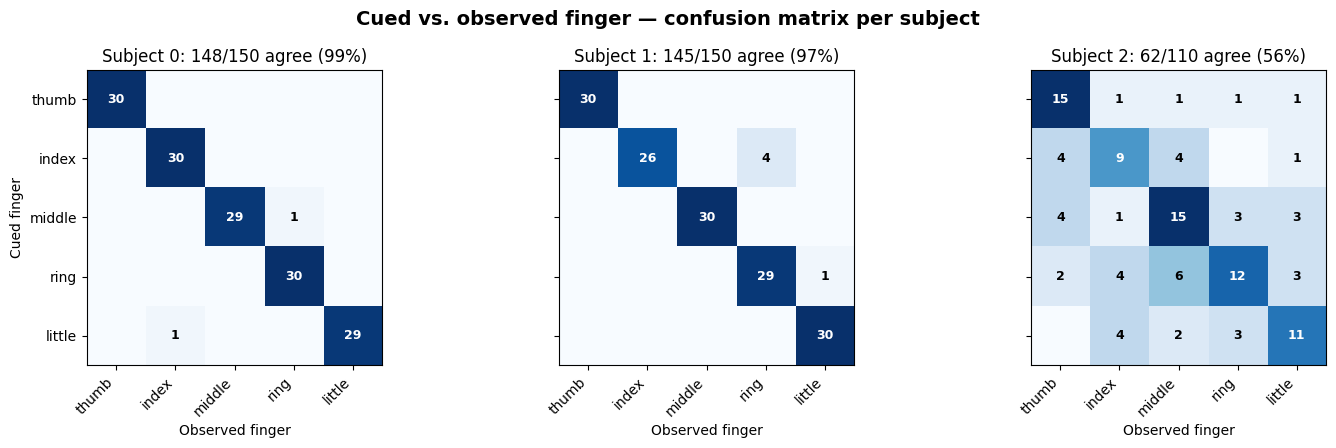

In [23]:
# ── Cross-subject: cued-vs-observed confusion matrix, per subject ──
# Same computation as Figure 2's left panel, repeated per subject using
# trials_df_all (built above). Never pooled — each subject's confusion
# matrix is its own, only the resulting counts/rates are compared side by
# side in the printed summary and the shared color scale below.

fig, axes = plt.subplots(1, len(alldat), figsize=(5 * len(alldat), 4.5))
if len(alldat) == 1:
    axes = [axes]

print("Cued-vs-observed agreement, per subject:")
print("-" * 60)
for s in range(len(alldat)):
    df = trials_df_all[s]
    n_agree = int(df["agree"].sum())
    n_total = len(df)
    print(f"  Subject {s}: {n_agree}/{n_total} agree ({100*n_agree/n_total:.1f}%), "
          f"{int(df['low_confidence'].sum())} low-confidence, "
          f"{int(df['include_in_decoding'].sum())} usable for decoding")

    conf = np.zeros((N_FINGERS, N_FINGERS), dtype=int)
    for cued, obs in zip(df["cued_finger"], df["observed_finger"]):
        conf[cued - 1, obs - 1] += 1

    ax = axes[s]
    im = ax.imshow(conf, cmap="Blues")
    ax.set_xticks(range(N_FINGERS)); ax.set_xticklabels(FINGER_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(N_FINGERS)); ax.set_yticklabels(FINGER_NAMES if s == 0 else [""] * N_FINGERS)
    ax.set_xlabel("Observed finger")
    if s == 0:
        ax.set_ylabel("Cued finger")
    ax.set_title(f"Subject {s}: {n_agree}/{n_total} agree ({100*n_agree/n_total:.0f}%)")
    for i in range(N_FINGERS):
        for j in range(N_FINGERS):
            if conf[i, j] > 0:
                ax.text(j, i, conf[i, j], ha="center", va="center",
                        color="white" if conf[i, j] > conf.max() / 2 else "black",
                        fontsize=9, fontweight="bold")

plt.suptitle("Cued vs. observed finger \u2014 confusion matrix per subject", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Observations:

Subject 0 (99% agreement, 148/150): Near-perfect compliance - mlmost all movement happened on diagonal (target finger).

Subject 1 (97% agreement, 145/150): Very high compliance. Small off-diagonal spillover (4 trials cued index but showed peak movement in ring), likely due to natural finger co-flexion.

Subject 2 (56% agreement, 62/110): Severe behavioral noise or glove artifact in nearly 44% of trials, the dominant movement occurred in a non-cued finger.

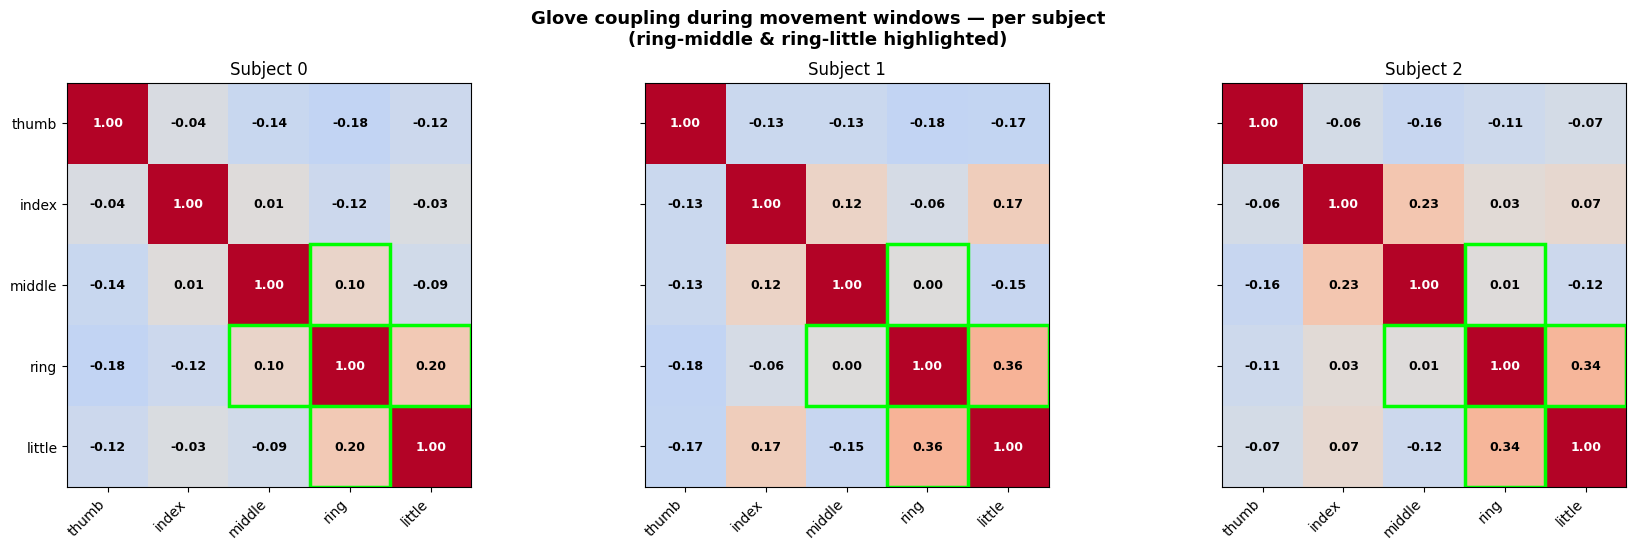

In [24]:
# ── Cross-subject: glove coupling matrix, per subject ────────────
# Same computation as Figure 3, repeated per subject: active-movement
# windows anchored on each subject's own trials_df_all onset_abs_sample.
# Never pooled — different channel/trial counts and glove calibration per
# subject; only the resulting correlation matrices are placed side by side.

POST_MOVE_S = 1.5
glove_corr_all = {}

fig, axes = plt.subplots(1, len(alldat), figsize=(6 * len(alldat), 5.5))
if len(alldat) == 1:
    axes = [axes]

for s in range(len(alldat)):
    srate_s = int(cleaned[s]["srate"])
    dg_s = cleaned[s]["dg"]
    post_samples_s = int(POST_MOVE_S * srate_s)

    move_segments = []
    for onset_sample in trials_df_all[s]["onset_abs_sample"]:
        if not np.isnan(onset_sample):
            m_start = int(onset_sample)
            m_end = int(onset_sample + post_samples_s)
            if m_end <= dg_s.shape[0]:
                move_segments.append(dg_s[m_start:m_end, :])

    move_data = np.concatenate(move_segments, axis=0)
    glove_corr = np.corrcoef(move_data, rowvar=False)
    glove_corr_all[s] = glove_corr

    ax = axes[s]
    im = ax.imshow(glove_corr, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(5)); ax.set_xticklabels(FINGER_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(FINGER_NAMES if s == 0 else [""] * 5)
    ax.set_title(f"Subject {s}")
    for i in range(5):
        for j in range(5):
            txt_color = "white" if np.abs(glove_corr[i, j]) > 0.5 else "black"
            ax.text(j, i, f"{glove_corr[i, j]:.2f}", ha="center", va="center",
                    color=txt_color, fontsize=9, fontweight="bold")
    ring_idx = 3
    for other in (2, 4):
        for (r, c) in [(ring_idx, other), (other, ring_idx)]:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                       edgecolor="lime", lw=2.5))

plt.suptitle("Glove coupling during movement windows \u2014 per subject\n(ring-middle & ring-little highlighted)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Observations: kinematic coupling (co-flexion) between fingers during active movement windows across all three subjects -


Ring and Little fingers consistently co-flex together r = 0.2-0.36 showing the strongest coupling so digits 4 and 5 must share common tendons, making independent ring finger movement biomechanically difficult.

Ring & Middle Finger show much lower coupling r = 0-0.1 indicating ring finger is more biomechanically bound to the little finger than to the middle finger.

Thumb and Index show near-zero or negative correlations with other fingers (r = -0.04 to -0.13$) which possibly shows their specialization for independent precision movement.

In [25]:
# ── Physiological Latency Filtering ─────────────────────────────
# Filter out anticipatory movements (< 150 ms) and non-responses (> 2000 ms)
MIN_LATENCY_MS = 150
MAX_LATENCY_MS = 2000

# Identify invalid trial indices
early_trials = np.where(onsets_rel_ms < MIN_LATENCY_MS)[0]
late_trials  = np.where(onsets_rel_ms > MAX_LATENCY_MS)[0]

print(f"Anticipatory/early trials (< {MIN_LATENCY_MS} ms): {list(early_trials)}")
print(f"Late/unresponsive trials (> {MAX_LATENCY_MS} ms): {list(late_trials)}")

# Invalidate out-of-bounds onsets
invalid_mask = (onsets_rel_ms < MIN_LATENCY_MS) | (onsets_rel_ms > MAX_LATENCY_MS)
onsets_rel_ms[invalid_mask] = np.nan

# Update absolute sample indices
onset_abs_samples[invalid_mask] = np.nan

# Updated summary
clean_onsets = np.sum(~np.isnan(onsets_rel_ms))
print(f"\nClean valid onsets remaining: {clean_onsets} / {n_trials}")
print(f"Adjusted average latency: {np.nanmean(onsets_rel_ms):.1f} ms")


Anticipatory/early trials (< 150 ms): []
Late/unresponsive trials (> 2000 ms): []

Clean valid onsets remaining: 133 / 150
Adjusted average latency: 800.0 ms


In [26]:
# ── Cross-subject: ring-coupling verdict ─────────────────────────
# Report, don't assert (Module 6 guardrail item 5): compute the
# neighbour-vs-distant coupling gap per subject from glove_corr_all above,
# and state a plain verdict. A null in any subject would be a finding to
# report, not something to average away.

ring_idx = 3
neighbour_idx = [2, 4]  # middle, little
distant_idx = [0, 1]    # thumb, index

print("Ring-finger coupling (neighbour minus distant), per subject:")
print("-" * 62)
verdicts = []
for s in range(len(alldat)):
    corr = glove_corr_all[s]
    ring_corrs = corr[ring_idx]
    neighbour_mean = float(np.mean([ring_corrs[i] for i in neighbour_idx]))
    distant_mean = float(np.mean([ring_corrs[i] for i in distant_idx]))
    gap = neighbour_mean - distant_mean
    verdict = "SUPPORTED" if gap > 0.10 else ("WEAK" if gap > 0 else "NULL")
    verdicts.append(verdict)
    print(f"  Subject {s}: neighbour={neighbour_mean:+.3f}, distant={distant_mean:+.3f}, "
          f"gap={gap:+.3f} -> {verdict}")

n_support = sum(v == "SUPPORTED" for v in verdicts)
print()
if n_support == len(alldat):
    print(f"CONSISTENT: ring-neighbour coupling SUPPORTED in all {len(alldat)} subjects "
          "\u2014 biomechanical premise generalises")
elif n_support >= 2:
    print(f"MOSTLY CONSISTENT: SUPPORTED in {n_support}/{len(alldat)} subjects "
          "\u2014 premise holds but note the exception(s).")
else:
    print(f"INCONSISTENT: SUPPORTED in only {n_support}/{len(alldat)} subjects "
          "\u2014 treat the coupling premise as subject-dependent, not general.")


Ring-finger coupling (neighbour minus distant), per subject:
--------------------------------------------------------------
  Subject 0: neighbour=+0.153, distant=-0.149, gap=+0.302 -> SUPPORTED
  Subject 1: neighbour=+0.178, distant=-0.118, gap=+0.296 -> SUPPORTED
  Subject 2: neighbour=+0.175, distant=-0.039, gap=+0.214 -> SUPPORTED

CONSISTENT: ring-neighbour coupling SUPPORTED in all 3 subjects — biomechanical premise generalises


## Next Steps — Abstract-Aligned Decoding & Modelling Plan

The EDA, signal pre-processing, and dataglove onset-detection pipeline are complete. The modelling team can proceed using the following, abstract-aligned execution plan:

### 1. Sliding Windows & Temporal Feature Slicing
* **Logic & Rationale:** Rather than taking a single static epoch, we slice the signal into **200-ms sliding windows** (step size: 50 ms) spanning **-400 ms to +400 ms** relative to movement onset ($t = 0$).
  * **Pinpointing Onset Dynamics:** Generates an *Accuracy vs. Time* curve to determine the exact millisecond interval when information becomes decodeable.
  * **Preparation vs. Execution:** Windows before $t = 0$ capture motor cortical planning; windows after $t = 0$ capture motor execution and peripheral sensory feedback.
  * **Noise Reduction & SNR:** Averaging power within each 200-ms window (`np.mean(..., axis=0)`) smooths sample-to-sample voltage fluctuations, yielding a stable feature vector `(n_trials, n_channels)` per window.
  * **BCI Latency Relevance:** Demonstrates how early a low-latency BCI decoder could issue a control command prior to physical movement.

### 2. Hypothesis-Driven Feature Decoding (Two-Stage / Double-Dissociation Architecture)
To test the core hypothesis that motor preparation employs two complementary spectral mechanisms:
* **Beta Band (12–20 Hz) $\rightarrow$ Binary Logistic Regression (Movement vs. Rest):**
  * **Hypothesis:** Beta-band desynchronization acts as an early, finger-non-specific **"gating" signal** (answering *"is a movement being prepared?"*).
  * **Setup:** Train a 2-class classifier ($y \in \{0=\text{Rest}, 1=\text{Movement}\}$) using `LogisticRegression(penalty='l2' or 'l1')`. Beta drop is expected to yield high binary decoding accuracy well before $t = 0$.
* **Broadband (70–115 Hz) $\rightarrow$ Multi-Class Logistic Regression (5-Finger Identity):**
  * **Hypothesis:** High-gamma/broadband power increases locally to provide a finger-specific **"selection" signal** (answering *"which specific finger is moving?"*).
  * **Setup:** Train a 5-class classifier ($y \in \{1, 2, 3, 4, 5\}$ from `final_label` filtered by `include_in_decoding == True`) using `LogisticRegression(multi_class='multinomial')`. Tracks the exact temporal window where 5-finger identity rises above chance.

### 3. Grid Search & Hyperparameter Tuning via Nested Cross-Validation
* **Guardrail Compliance:** Execute hyperparameter search using **Nested Cross-Validation** (outer 5-fold CV for evaluation; inner `GridSearchCV` on training folds only) to eliminate data leakage.
* **Tuning Parameters:**
  * **Regularization Strength ($C$):** Search grid `[0.001, 0.01, 0.1, 1.0, 10.0]`.
  * **Penalty Formulation:** Compare `L1` (Lasso — drives channel sparsity to isolate key motor electrodes) vs. `L2` (Ridge).
  * **Dominance Margin Sensitivity:** Test `LOW_MARGIN_THRESHOLD` over `[0.05, 0.10, 0.20]` to verify that results are robust against single-finger trial selection criteria.

### 4. Validation, Permutation Testing & Statistical Baselines
* **Subject-Specific Evaluation:** Train models per subject independently (never pool channels across subjects given clinical electrode coverage differences).
* **Statistical Significance:** Run label-permutation tests (shuffling labels 500+ times) and compute bootstrap confidence intervals around onset latency to establish chance baselines (20% for 5-finger, 50% for binary).


In [36]:
# ── Module 5, Step 1: Sliding windows & temporal feature slicing ──
# Cut the continuous broadband/beta envelopes into 200-ms windows spanning
# -400ms to +400ms around each trial's movement onset (t=0). Anchored on
# onset_abs_sample from trials_df_all[subj] (NOT the cue) so windows are
# relative to when the finger actually started moving. Non-overlapping
# 200-ms windows over the 800-ms span -> 4 windows/trial:
# [-400,-200), [-200,0), [0,200), [200,400) ms.
# Every subject kept separate (own channel count / own onsets) per the
# no-pooling guardrail used throughout.

WINDOW_MS    = 200     # window width (ms)
WIN_START_MS = -400    # window range start, relative to onset
WIN_END_MS   = 400      # window range end, relative to onset


def slice_feature_windows(feature, onset_samples, srate,
                           window_ms=WINDOW_MS,
                           win_start_ms=WIN_START_MS,
                           win_end_ms=WIN_END_MS):
    """
    Slice a continuous per-channel feature timecourse into fixed-width
    windows anchored on each trial's movement onset.

    Parameters
    ----------
    feature       : ndarray, shape (n_samples, n_channels) — z-scored
                    envelope (broadband[subj] or beta[subj])
    onset_samples : array of per-trial onset sample indices (NaN = no
                    valid onset -> trial skipped)
    srate         : int — sampling rate (Hz)

    Returns
    -------
    windows         : ndarray, shape (n_trials, n_windows, n_channels) —
                       mean feature value per window per channel; rows
                       for trials with no valid onset (or an out-of-range
                       window) stay NaN.
    window_edges_ms : list of (start_ms, end_ms) per window, onset-relative
                       — labels the windows axis of `windows`.
    """
    win_samples  = int(round(window_ms / 1000 * srate))
    start_offset = int(round(win_start_ms / 1000 * srate))
    n_windows    = int(round((win_end_ms - win_start_ms) / window_ms))
    n_channels   = feature.shape[1]
    n_trials     = len(onset_samples)

    windows = np.full((n_trials, n_windows, n_channels), np.nan, dtype=np.float32)
    window_edges_ms = [(win_start_ms + w * window_ms, win_start_ms + (w + 1) * window_ms)
                        for w in range(n_windows)]

    for trial_idx, onset in enumerate(onset_samples):
        if np.isnan(onset):
            continue
        onset = int(onset)
        for w in range(n_windows):
            w_start = onset + start_offset + w * win_samples
            w_end   = w_start + win_samples
            if w_start >= 0 and w_end <= feature.shape[0]:
                windows[trial_idx, w, :] = feature[w_start:w_end, :].mean(axis=0)

    return windows, window_edges_ms


# Build windowed broadband + beta features per subject, anchored on that
# subject's own onset_abs_sample from trials_df_all (never pooled).
broadband_windows = {}
beta_windows = {}
window_edges_ms = None

for subj in range(len(alldat)):
    srate = int(cleaned[subj]['srate'])
    onset_samples = trials_df_all[subj]['onset_abs_sample'].values

    broadband_windows[subj], window_edges_ms = slice_feature_windows(broadband[subj], onset_samples, srate)
    beta_windows[subj], _                    = slice_feature_windows(beta[subj], onset_samples, srate)

    n_valid = int(np.sum(~np.isnan(onset_samples)))
    print(f"Subject {subj}: windows {broadband_windows[subj].shape} "
          f"({n_valid}/{len(onset_samples)} trials with a valid onset) — "
          f"edges(ms) {window_edges_ms}")


Subject 0: windows (150, 4, 84) (133/150 trials with a valid onset) — edges(ms) [(-400, -200), (-200, 0), (0, 200), (200, 400)]
Subject 1: windows (150, 4, 62) (122/150 trials with a valid onset) — edges(ms) [(-400, -200), (-200, 0), (0, 200), (200, 400)]
Subject 2: windows (110, 4, 78) (73/110 trials with a valid onset) — edges(ms) [(-400, -200), (-200, 0), (0, 200), (200, 400)]


In [37]:
# ── Step 2a: cue-locked rest baseline for the beta binary task ───
# beta_windows[subj] is anchored on movement onset only, so there is no "rest" data yet. Reuse slice_feature_windows() itself, anchored on
# t_on (the CUE, not the movement) with a single 200-ms window ending exactly at cue onset: win_start_ms=-WINDOW_MS, win_end_ms=0. This is
# strictly pre-cue -> free of any cue-triggered prep signal or movement, and sits inside the 500-ms pre-cue baseline (BASELINE_S) already
# assumed available per trial. Kept per-subject, never pooled.

beta_rest_windows = {}
rest_edges_ms = None

for subj in range(len(alldat)):
    srate = int(cleaned[subj]['srate'])
    t_on = cleaned[subj]['t_on'].flatten().astype(float)

    beta_rest_windows[subj], rest_edges_ms = slice_feature_windows(
        beta[subj], t_on, srate, win_start_ms=-WINDOW_MS, win_end_ms=0)

    n_valid = int(np.sum(~np.isnan(beta_rest_windows[subj][:, 0, :]).any(axis=1)))
    print(f"Subject {subj}: rest window {beta_rest_windows[subj].shape} "
          f"({n_valid}/{len(t_on)} trials valid) — edge(ms) {rest_edges_ms}")


Subject 0: rest window (150, 1, 84) (150/150 trials valid) — edge(ms) [(-200, 0)]
Subject 1: rest window (150, 1, 62) (150/150 trials valid) — edge(ms) [(-200, 0)]
Subject 2: rest window (110, 1, 78) (110/110 trials valid) — edge(ms) [(-200, 0)]


In [38]:
# ── Step 2b: per-(subject, window) dataset assembly for both tasks ──
# Stable interface — Step 3 swaps only the classifier below; these
# functions don't change when nested CV / grid search is added.

def valid_rows(window_slice):
    """Boolean mask over trials: True where every channel is finite for
    this (subject, window) slice, shape (n_trials, n_channels)."""
    return ~np.isnan(window_slice).any(axis=1)


def assemble_broadband_dataset(subj, w):
    """Broadband 5-way finger-identity dataset for window w of subject
    subj. Rows: include_in_decoding == True and window has no NaNs.
    Returns (X, y) with y = final_label (values 1..5)."""
    df = trials_df_all[subj]
    window_slice = broadband_windows[subj][:, w, :]
    mask = df['include_in_decoding'].values & valid_rows(window_slice)
    return window_slice[mask], df['final_label'].values[mask].astype(int)


def assemble_beta_dataset(subj, w):
    """Beta movement-vs-rest dataset for window w of subject subj.
    Rows: valid onset_abs_sample, matched with that trial's own
    cue-locked rest window. Returns (X, y): y=1 for the movement
    window, y=0 for the matched rest window -> balanced 50/50."""
    df = trials_df_all[subj]
    move_slice = beta_windows[subj][:, w, :]
    rest_slice = beta_rest_windows[subj][:, 0, :]
    mask = df['onset_abs_sample'].notna().values & valid_rows(move_slice) & valid_rows(rest_slice)
    X = np.vstack([move_slice[mask], rest_slice[mask]])
    y = np.concatenate([np.ones(mask.sum()), np.zeros(mask.sum())])
    return X, y


# Sanity-print dataset sizes before any modeling
for subj in range(len(alldat)):
    for w, (s_ms, e_ms) in enumerate(window_edges_ms):
        Xb, yb = assemble_broadband_dataset(subj, w)
        Xr, yr = assemble_beta_dataset(subj, w)
        print(f"Subject {subj} window [{s_ms},{e_ms})ms — "
              f"broadband: n={len(yb)}, class counts={np.bincount(yb)[1:]}; "
              f"beta: n={len(yr)} (movement={int(yr.sum())}, rest={int((yr==0).sum())})")


Subject 0 window [-400,-200)ms — broadband: n=132, class counts=[28 26 25 26 27]; beta: n=266 (movement=133, rest=133)
Subject 0 window [-200,0)ms — broadband: n=132, class counts=[28 26 25 26 27]; beta: n=266 (movement=133, rest=133)
Subject 0 window [0,200)ms — broadband: n=132, class counts=[28 26 25 26 27]; beta: n=266 (movement=133, rest=133)
Subject 0 window [200,400)ms — broadband: n=132, class counts=[28 26 25 26 27]; beta: n=266 (movement=133, rest=133)
Subject 1 window [-400,-200)ms — broadband: n=122, class counts=[29 20 22 28 23]; beta: n=244 (movement=122, rest=122)
Subject 1 window [-200,0)ms — broadband: n=122, class counts=[29 20 22 28 23]; beta: n=244 (movement=122, rest=122)
Subject 1 window [0,200)ms — broadband: n=122, class counts=[29 20 22 28 23]; beta: n=244 (movement=122, rest=122)
Subject 1 window [200,400)ms — broadband: n=122, class counts=[29 20 22 28 23]; beta: n=244 (movement=122, rest=122)
Subject 2 window [-400,-200)ms — broadband: n=65, class counts=[17

###

In [40]:
# ── Step 3: Nested CV (outer eval / inner grid search) ──
# Outer StratifiedKFold = honest evaluation; GridSearchCV inside each outer
# training fold = hyperparameter selection. Test folds never touch the grid
# search, so there's no leakage from tuning into the reported score.

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

C_GRID       = [0.001, 0.01, 0.1, 1.0, 10.0]
PENALTY_GRID = ["l1", "l2"]
OUTER_K      = 5
INNER_K      = 3

def make_binary_pipeline(random_state=42):
    # liblinear supports l1 and l2 natively and is stable on small binary
    # folds -> avoids the saga convergence tuning that isn't needed here.
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("classifier", LogisticRegression(solver="liblinear", random_state=random_state, max_iter=2000)),
    ])

def make_multiclass_pipeline(random_state=42):
    # saga is required for true multinomial + l1/l2 support on 5-way labels
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("classifier", LogisticRegression(solver="saga",
                                           random_state=random_state, max_iter=5000)),
    ])

def nested_cv_binary(X, y, outer_k=OUTER_K, inner_k=INNER_K,
                      c_grid=C_GRID, penalty_grid=PENALTY_GRID, random_state=42):
    counts = np.unique(y.astype(int), return_counts=True)[1]      # <- was np.bincount(y.astype(int))
    if len(counts) < 2 or counts.min() < outer_k:
        return None

    outer_cv = StratifiedKFold(n_splits=outer_k, shuffle=True, random_state=random_state)
    param_grid = {"classifier__C": c_grid, "classifier__penalty": penalty_grid}

    cv_results = []
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        inner_k_eff = min(inner_k, np.unique(y_train.astype(int), return_counts=True)[1].min())
        inner_cv = StratifiedKFold(n_splits=inner_k_eff, shuffle=True, random_state=random_state)

        gs = GridSearchCV(make_binary_pipeline(random_state), param_grid,
                           scoring="roc_auc", cv=inner_cv, n_jobs=-1)
        gs.fit(X_train, y_train)

        best = gs.best_estimator_
        y_pred_proba = best.predict_proba(X_test)[:, 1]
        cv_results.append({
            "fold": fold_idx, "y_test": y_test, "y_pred_proba": y_pred_proba,
            "test_auc": roc_auc_score(y_test, y_pred_proba),
            "best_params": gs.best_params_,
        })
    return cv_results

def nested_cv_multiclass(X, y, outer_k=OUTER_K, inner_k=INNER_K,
                          c_grid=C_GRID, penalty_grid=PENALTY_GRID, random_state=42):
    counts = np.unique(y.astype(int), return_counts=True)[1]
    if len(counts) < 2 or counts.min() < outer_k:
        return None

    outer_cv = StratifiedKFold(n_splits=outer_k, shuffle=True, random_state=random_state)
    param_grid = {"classifier__C": c_grid, "classifier__penalty": penalty_grid}

    cv_results = []
    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        inner_k_eff = min(inner_k, np.unique(y_train.astype(int), return_counts=True)[1].min())
        inner_cv = StratifiedKFold(n_splits=inner_k_eff, shuffle=True, random_state=random_state)



        gs = GridSearchCV(make_multiclass_pipeline(random_state), param_grid,
                           scoring="accuracy", cv=inner_cv, n_jobs=-1)
        gs.fit(X_train, y_train)

        best = gs.best_estimator_
        y_pred = best.predict(X_test)
        cv_results.append({
            "fold": fold_idx, "y_test": y_test, "y_pred": y_pred,
            "test_acc": accuracy_score(y_test, y_pred),
            "best_params": gs.best_params_,
        })

    return cv_results

In [41]:
# ── Run nested CV per subject, per window ──
beta_nested_results       = {subj: {} for subj in range(len(alldat))}
broadband_nested_results  = {subj: {} for subj in range(len(alldat))}

for subj in range(len(alldat)):
    for w, (s_ms, e_ms) in enumerate(window_edges_ms):
        Xr, yr = assemble_beta_dataset(subj, w)
        beta_nested_results[subj][w] = nested_cv_binary(Xr, yr)

        Xb, yb = assemble_broadband_dataset(subj, w)
        broadband_nested_results[subj][w] = nested_cv_multiclass(Xb, yb)

        beta_ok = beta_nested_results[subj][w] is not None
        bb_ok   = broadband_nested_results[subj][w] is not None
        print(f"Subject {subj} window [{s_ms},{e_ms})ms — "
              f"beta nested-CV: {'ok' if beta_ok else 'skipped (too few trials)'} | "
              f"broadband nested-CV: {'ok' if bb_ok else 'skipped (too few trials)'}")

Subject 0 window [-400,-200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 0 window [-200,0)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 0 window [0,200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 0 window [200,400)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 1 window [-400,-200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 1 window [-200,0)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 1 window [0,200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 1 window [200,400)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 2 window [-400,-200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 2 window [-200,0)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 2 window [0,200)ms — beta nested-CV: ok | broadband nested-CV: ok
Subject 2 window [200,400)ms — beta nested-CV: ok | broadband nested-CV: ok


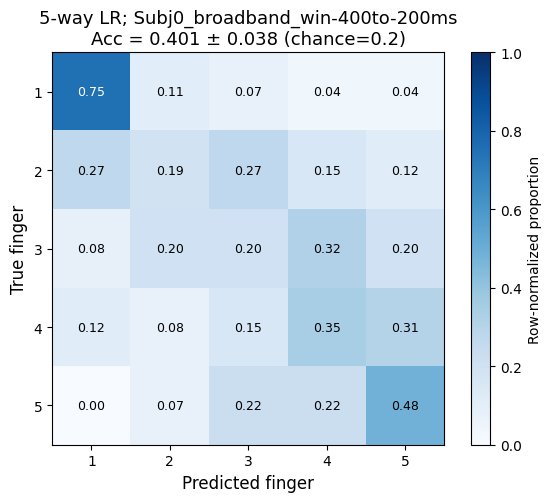

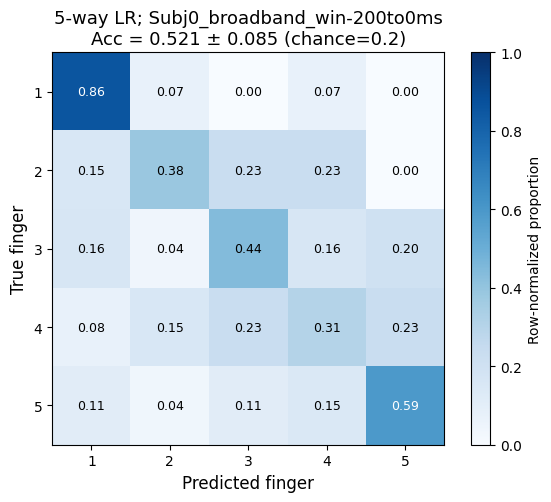

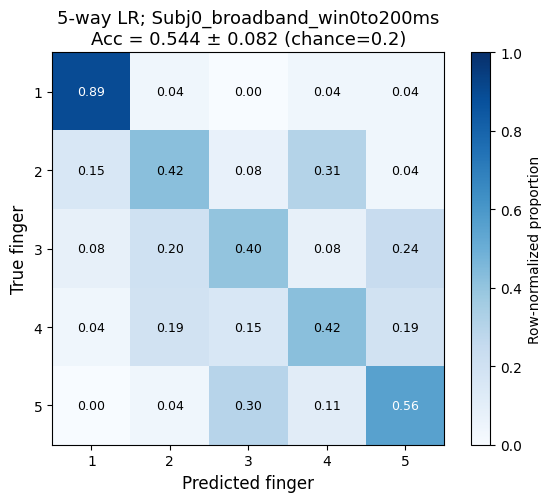

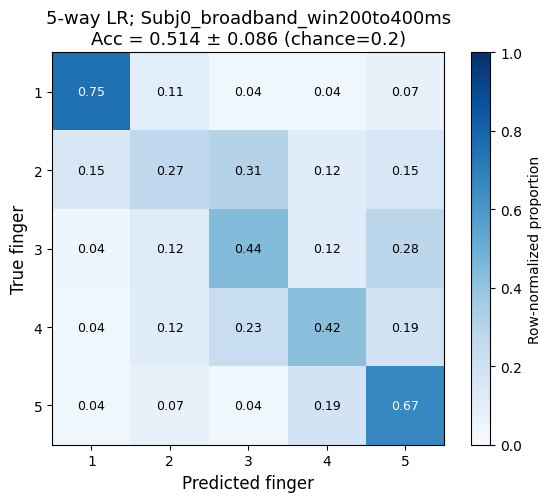

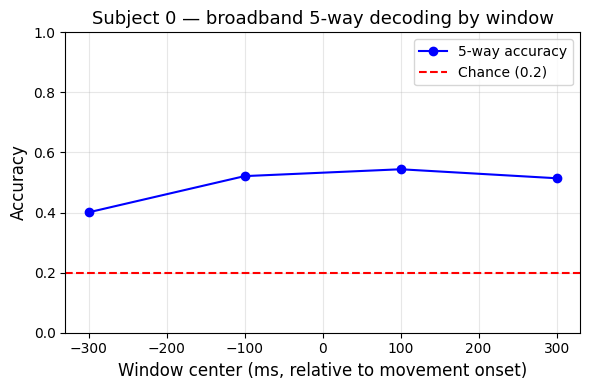

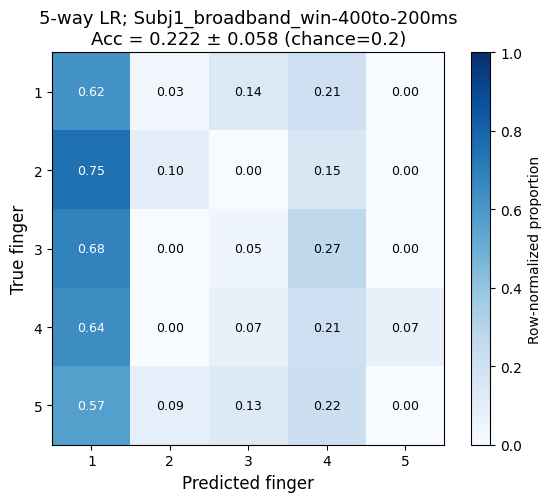

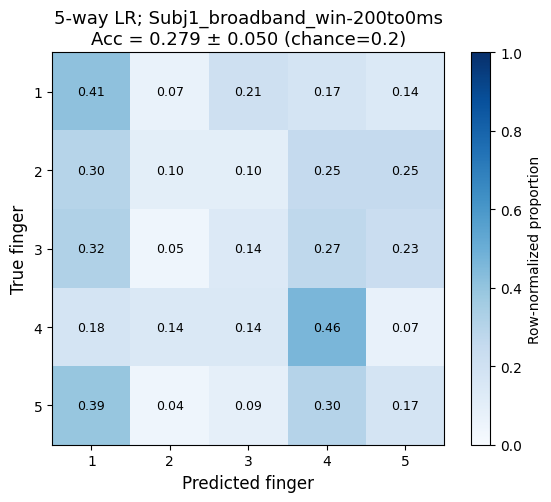

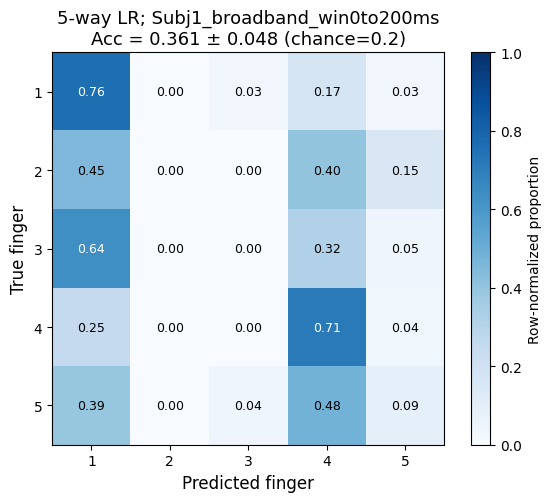

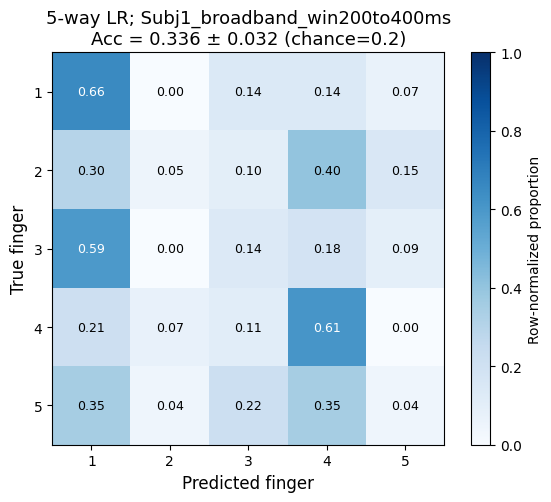

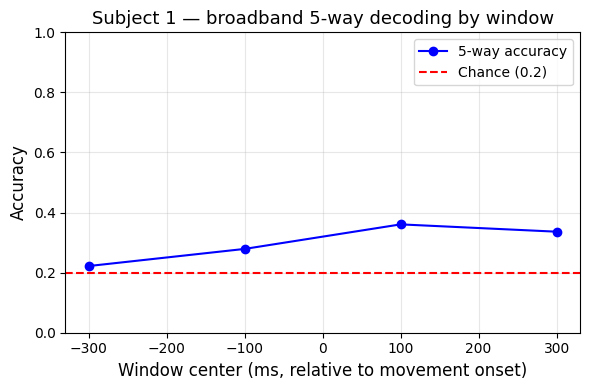

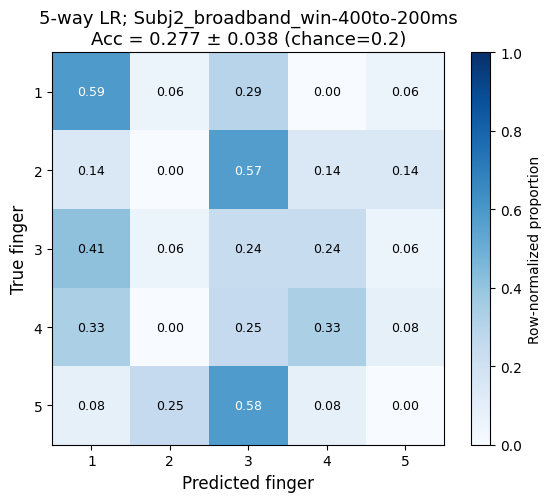

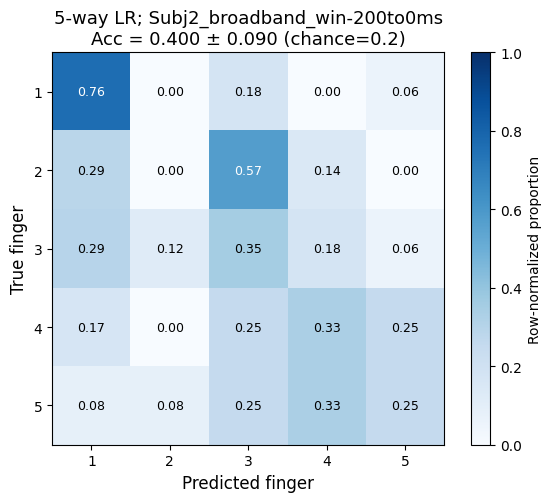

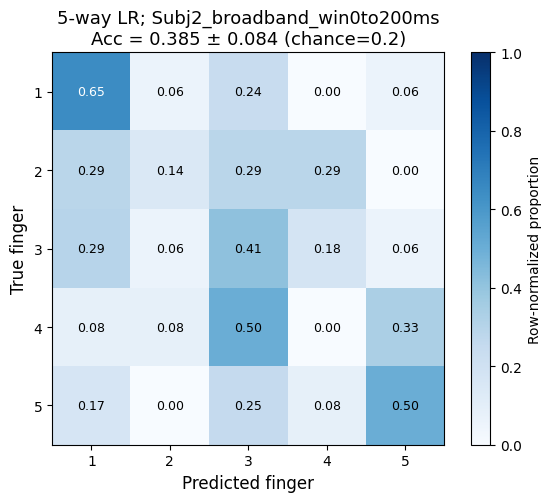

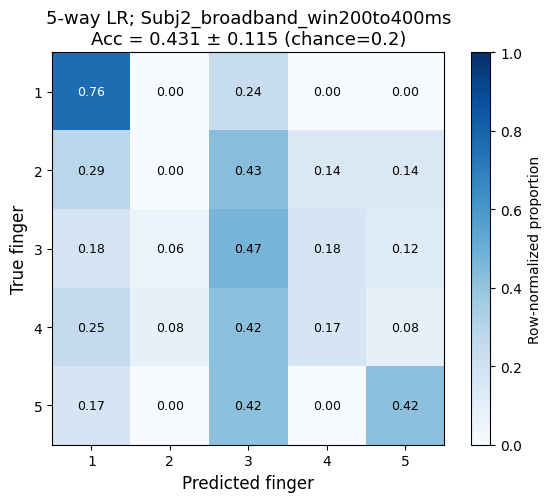

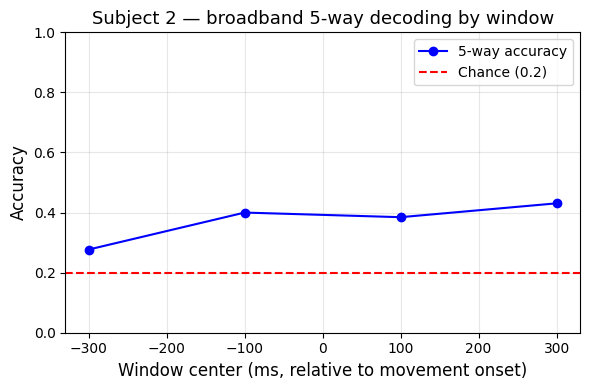

In [43]:
# ── Confusion matrices (row per subject) + accuracy w/ CI & null band + per-finger recall ──
from sklearn.metrics import confusion_matrix
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

CHANCE_5WAY = 0.2
LABELS = (1, 2, 3, 4, 5)

def fold_accs_and_ci(cv_results, conf=0.95):
    """Mean + t-based CI across outer folds (n is small, so use t not z)."""
    accs = np.array([r['test_acc'] for r in cv_results])
    n = len(accs)
    mean = accs.mean()
    if n < 2:
        return mean, mean, mean
    sem = accs.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf((1 + conf) / 2, df=n - 1)
    return mean, mean - tcrit * sem, mean + tcrit * sem

def plot_confusion_row(cv_results_by_window, window_edges_ms, subj):
    """One row of confusion matrices, one per window, shared colorbar."""
    n_w = len(window_edges_ms)
    fig, axes = plt.subplots(1, n_w, figsize=(4.2 * n_w, 4.5),
                              sharey=True, constrained_layout=True)
    if n_w == 1:
        axes = [axes]

    im = None
    for w, (s_ms, e_ms) in enumerate(window_edges_ms):
        ax = axes[w]
        cv_results = cv_results_by_window[w]
        if cv_results is None:
            ax.set_title(f"[{s_ms},{e_ms})ms\nskipped", fontsize=11)
            ax.axis('off')
            continue

        y_test = np.concatenate([r['y_test'] for r in cv_results])
        y_pred = np.concatenate([r['y_pred'] for r in cv_results])
        cm = confusion_matrix(y_test, y_pred, labels=LABELS)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        mean_acc, lo, hi = fold_accs_and_ci(cv_results)

        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='equal')
        ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, fontsize=10)
        ax.set_xlabel("Predicted finger", fontsize=11)
        if w == 0:
            ax.set_yticks(range(len(LABELS)))
            ax.set_yticklabels(LABELS, fontsize=10)
            ax.set_ylabel("True finger", fontsize=11)
        ax.set_title(f"[{s_ms},{e_ms})ms\nacc={mean_acc:.2f} [{lo:.2f},{hi:.2f}]", fontsize=11)

        for i in range(len(LABELS)):
            for j in range(len(LABELS)):
                ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha='center', va='center',
                         color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=9)

    fig.suptitle(f"Subject {subj} — broadband 5-way confusion by window", fontsize=14, fontweight='bold')
    if im is not None:
        fig.colorbar(im, ax=axes, label="Row-normalized proportion", shrink=0.85, pad=0.02)
    plt.show()

def plot_accuracy_ci_and_null(cv_results_by_window, perm_results_by_window, window_edges_ms, subj):
    win_centers = [(s + e) / 2 for s, e in window_edges_ms]
    means, los, his, null_los, null_his, sig = [], [], [], [], [], []

    for w in range(len(window_edges_ms)):
        cv_results = cv_results_by_window[w]
        perm = perm_results_by_window[w]
        if cv_results is None:
            means.append(np.nan); los.append(np.nan); his.append(np.nan)
            null_los.append(np.nan); null_his.append(np.nan); sig.append(False)
            continue
        m, lo, hi = fold_accs_and_ci(cv_results)
        means.append(m); los.append(lo); his.append(hi)
        if perm is not None:
            null_los.append(np.percentile(perm['null_scores'], 2.5))
            null_his.append(np.percentile(perm['null_scores'], 97.5))
            sig.append(m > np.percentile(perm['null_scores'], 95))
        else:
            null_los.append(np.nan); null_his.append(np.nan); sig.append(False)

    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
    ax.fill_between(win_centers, null_los, null_his, color='gray', alpha=0.25,
                     label='Null 95% band (permutation)')
    ax.fill_between(win_centers, los, his, color='b', alpha=0.2, label='95% CI (outer folds)')
    ax.plot(win_centers, means, marker='o', color='b', linewidth=2, label='5-way accuracy')
    ax.axhline(CHANCE_5WAY, color='r', linestyle='--', linewidth=1, label='Theoretical chance (0.2)')

    for x, m, s in zip(win_centers, means, sig):
        if s:
            ax.annotate('*', (x, m), textcoords="offset points", xytext=(0, 10),
                        ha='center', fontsize=18, color='darkgreen', fontweight='bold')

    ax.set_xlabel("Window center (ms, relative to movement onset)", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(f"Subject {subj} — broadband 5-way decoding by window\n(* = beats permutation null, p<0.05)",
                 fontsize=13)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_per_finger_recall(cv_results_by_window, window_edges_ms, subj, finger_names=FINGER_NAMES):
    win_centers = [(s + e) / 2 for s, e in window_edges_ms]
    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
    for finger_idx, finger_label in enumerate(LABELS):
        recalls = []
        for w in range(len(window_edges_ms)):
            cv_results = cv_results_by_window[w]
            if cv_results is None:
                recalls.append(np.nan)
                continue
            y_test = np.concatenate([r['y_test'] for r in cv_results])
            y_pred = np.concatenate([r['y_pred'] for r in cv_results])
            mask = y_test == finger_label
            recalls.append(np.mean(y_pred[mask] == finger_label) if mask.sum() else np.nan)
        ax.plot(win_centers, recalls, marker='o', linewidth=2, label=finger_names[finger_idx])
    ax.axhline(CHANCE_5WAY, color='r', linestyle='--', linewidth=1, label='Chance (0.2)')
    ax.set_xlabel("Window center (ms, relative to movement onset)", fontsize=12)
    ax.set_ylabel("Per-finger recall", fontsize=12)
    ax.set_title(f"Subject {subj} — which finger decodes first?", fontsize=13)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.show()

for subj in range(len(alldat)):
    plot_confusion_row(broadband_nested_results[subj], window_edges_ms, subj)
    plot_accuracy_ci_and_null(broadband_nested_results[subj], broadband_perm_results[subj],
                               window_edges_ms, subj)
    plot_per_finger_recall(broadband_nested_results[subj], window_edges_ms, subj)

In [44]:
# ── LOW_MARGIN_THRESHOLD sensitivity (broadband task) ──
# NOTE: this assumes an existing upstream function that rebuilds
# trials_df_all given a margin threshold (the step that produces
# final_label / include_in_decoding, upstream of Step 2b). Point
# rebuild_trials_df_all at your actual function — this is a placeholder
# so the harness runs once that's wired in.

MARGIN_THRESHOLDS = [0.05, 0.10, 0.20]
margin_sensitivity_results = {}

def rebuild_trials_df_all(alldat, cleaned, low_margin_threshold):
    return {
        subj: compute_trials_df(
            subj,
            low_margin_threshold=low_margin_threshold
        )
        for subj in range(len(alldat))
    }

for thr in MARGIN_THRESHOLDS:
    trials_df_thr = rebuild_trials_df_all(alldat, cleaned, thr)

    thr_results = {subj: {} for subj in range(len(alldat))}
    for subj in range(len(alldat)):
        df = trials_df_thr[subj]
        for w, (s_ms, e_ms) in enumerate(window_edges_ms):
            window_slice = broadband_windows[subj][:, w, :]
            mask = df['include_in_decoding'].values & valid_rows(window_slice)
            Xb, yb = window_slice[mask], df['final_label'].values[mask].astype(int)
            thr_results[subj][w] = nested_cv_multiclass(Xb, yb)

    margin_sensitivity_results[thr] = thr_results
    print(f"LOW_MARGIN_THRESHOLD={thr}: done")

# Robustness check: compare mean test_acc across thresholds per subject/window
for subj in range(len(alldat)):
    for w, (s_ms, e_ms) in enumerate(window_edges_ms):
        accs = []
        for thr in MARGIN_THRESHOLDS:
            res = margin_sensitivity_results[thr][subj][w]
            accs.append(np.mean([r["test_acc"] for r in res]) if res else np.nan)
        print(f"Subj {subj} win[{s_ms},{e_ms}) — acc by margin {MARGIN_THRESHOLDS}: "
              f"{[round(a,3) if not np.isnan(a) else None for a in accs]}")

Subject 0: 150 trials — 148 agree / 2 disagree, 2 low-confidence (margin < 0.05), 132 usable for decoding
Subject 1: 150 trials — 145 agree / 5 disagree, 0 low-confidence (margin < 0.05), 122 usable for decoding
Subject 2: 110 trials — 62 agree / 48 disagree, 13 low-confidence (margin < 0.05), 66 usable for decoding
LOW_MARGIN_THRESHOLD=0.05: done
Subject 0: 150 trials — 148 agree / 2 disagree, 2 low-confidence (margin < 0.1), 132 usable for decoding
Subject 1: 150 trials — 145 agree / 5 disagree, 0 low-confidence (margin < 0.1), 122 usable for decoding
Subject 2: 110 trials — 62 agree / 48 disagree, 20 low-confidence (margin < 0.1), 65 usable for decoding
LOW_MARGIN_THRESHOLD=0.1: done
Subject 0: 150 trials — 148 agree / 2 disagree, 2 low-confidence (margin < 0.2), 132 usable for decoding
Subject 1: 150 trials — 145 agree / 5 disagree, 0 low-confidence (margin < 0.2), 122 usable for decoding
Subject 2: 110 trials — 62 agree / 48 disagree, 26 low-confidence (margin < 0.2), 61 usable fo

In [46]:
# ── Permutation testing (label shuffling, 500+ reps) ──
# Uses a single fixed model (C=1.0, L2) rather than nested grid search per
# permutation — 500 permutations x full grid search per (subject, window)
# is computationally impractical. This gives a valid null distribution for
# "does this window decode better than chance," separate from the
# tuned-model performance estimates above.

from sklearn.model_selection import permutation_test_score

N_PERMUTATIONS = 500

def run_permutation_test(X, y, task="binary", n_permutations=N_PERMUTATIONS, cv_k=5, random_state=42):
    counts = np.unique(y.astype(int), return_counts=True)[1]      # <- was np.bincount(y.astype(int))
    if len(counts) < 2 or counts.min() < cv_k:
        return None

    if task == "binary":
        pipe = make_binary_pipeline(random_state)
        pipe.set_params(classifier__C=1.0, classifier__penalty="l2")
        scoring, chance = "roc_auc", 0.5
    else:
        pipe = make_multiclass_pipeline(random_state)
        pipe.set_params(classifier__C=1.0, classifier__penalty="l2")
        scoring, chance = "accuracy", 1.0 / len(counts)

    cv = StratifiedKFold(n_splits=cv_k, shuffle=True, random_state=random_state)
    score, null_scores, pvalue = permutation_test_score(
        pipe, X, y, scoring=scoring, cv=cv, n_permutations=n_permutations,
        n_jobs=-1, random_state=random_state)

    return {"observed_score": score, "null_scores": null_scores, "p_value": pvalue, "chance": chance}

beta_perm_results       = {subj: {} for subj in range(len(alldat))}
broadband_perm_results  = {subj: {} for subj in range(len(alldat))}

for subj in range(len(alldat)):
    for w, (s_ms, e_ms) in enumerate(window_edges_ms):
        Xr, yr = assemble_beta_dataset(subj, w)
        beta_perm_results[subj][w] = run_permutation_test(Xr, yr, task="binary")

        Xb, yb = assemble_broadband_dataset(subj, w)
        broadband_perm_results[subj][w] = run_permutation_test(Xb, yb, task="multiclass")

        bp, bbp = beta_perm_results[subj][w], broadband_perm_results[subj][w]
        beta_msg = f"AUC={bp['observed_score']:.3f}, p={bp['p_value']:.4f}" if bp else "skipped"
        bb_msg   = f"acc={bbp['observed_score']:.3f}, p={bbp['p_value']:.4f}" if bbp else "skipped"
        print(f"Subj {subj} win[{s_ms},{e_ms}) — beta perm: {beta_msg} | broadband perm: {bb_msg}")

Subj 0 win[-400,-200) — beta perm: AUC=0.731, p=0.0020 | broadband perm: acc=0.423, p=0.0020
Subj 0 win[-200,0) — beta perm: AUC=0.818, p=0.0020 | broadband perm: acc=0.507, p=0.0020
Subj 0 win[0,200) — beta perm: AUC=0.861, p=0.0020 | broadband perm: acc=0.515, p=0.0020


KeyboardInterrupt: 

In [47]:
# ── Bootstrap CI on decoding onset latency ──
# Onset latency = earliest window whose CV score clears its permutation-
# derived significance threshold. Resample trials with replacement per
# bootstrap draw, recompute per-window scores, record the first window
# that clears threshold; draws where nothing clears contribute NaN and
# are excluded from the CI (frac_significant reports how often that happens).

N_BOOTSTRAP = 1000

def sig_threshold(perm_result, alpha=0.05):
    return np.quantile(perm_result["null_scores"], 1 - alpha) if perm_result else np.inf

def bootstrap_onset_latency(X_by_window, y_by_window, perm_results_by_window,
                             window_edges_ms, task="binary", n_boot=N_BOOTSTRAP,
                             cv_k=5, random_state=42):
    rng = np.random.default_rng(random_state)
    thresholds = [sig_threshold(perm_results_by_window[w]) for w in range(len(window_edges_ms))]

    latencies = []
    for b in range(n_boot):
        onset_latency = np.nan
        for w in range(len(window_edges_ms)):
            X, y = X_by_window[w], y_by_window[w]
            if X is None or len(y) < cv_k * 2:
                continue
            idx = rng.integers(0, len(y), size=len(y))
            Xb, yb = X[idx], y[idx]
            if len(np.unique(yb)) < 2:
                continue

            pipe = make_binary_pipeline(random_state) if task == "binary" else make_multiclass_pipeline(random_state)
            pipe.set_params(classifier__C=1.0, classifier__penalty="l2")
            scoring = "roc_auc" if task == "binary" else "accuracy"

            try:
                k_eff = min(cv_k, np.unique(yb.astype(int), return_counts=True)[1].min())
                cv = StratifiedKFold(n_splits=k_eff, shuffle=True, random_state=random_state)
                score = cross_val_score(pipe, Xb, yb, scoring=scoring, cv=cv, n_jobs=-1).mean()
            except ValueError:
                continue

            if score >= thresholds[w]:
                onset_latency = window_edges_ms[w][0]
                break
        latencies.append(onset_latency)

    latencies = np.array(latencies, dtype=float)
    valid = latencies[~np.isnan(latencies)]
    if len(valid) == 0:
        return {"latencies": latencies, "median": np.nan, "ci": (np.nan, np.nan), "frac_significant": 0.0}

    ci_low, ci_high = np.percentile(valid, [2.5, 97.5])
    return {"latencies": latencies, "median": np.median(valid), "ci": (ci_low, ci_high),
            "frac_significant": len(valid) / n_boot}

onset_latency_beta, onset_latency_broadband = {}, {}

for subj in range(len(alldat)):
    Xw_beta, yw_beta, Xw_bb, yw_bb = [], [], [], []
    for w in range(len(window_edges_ms)):
        Xr, yr = assemble_beta_dataset(subj, w); Xw_beta.append(Xr); yw_beta.append(yr)
        Xb, yb = assemble_broadband_dataset(subj, w); Xw_bb.append(Xb); yw_bb.append(yb)

    onset_latency_beta[subj] = bootstrap_onset_latency(
        Xw_beta, yw_beta, beta_perm_results[subj], window_edges_ms, task="binary")
    onset_latency_broadband[subj] = bootstrap_onset_latency(
        Xw_bb, yw_bb, broadband_perm_results[subj], window_edges_ms, task="multiclass")

    ob, obb = onset_latency_beta[subj], onset_latency_broadband[subj]
    print(f"Subj {subj} — beta onset: median={ob['median']:.0f}ms, "
          f"95%CI=({ob['ci'][0]:.0f},{ob['ci'][1]:.0f})ms, sig-rate={ob['frac_significant']*100:.0f}% | "
          f"broadband onset: median={obb['median']:.0f}ms, "
          f"95%CI=({obb['ci'][0]:.0f},{obb['ci'][1]:.0f})ms, sig-rate={obb['frac_significant']*100:.0f}%")

KeyError: 3

In [ ]:
# ── Plot: margin-threshold sensitivity, small multiples per subject ──
import matplotlib.pyplot as plt
import numpy as np

def plot_margin_sensitivity(margin_sensitivity_results, window_edges_ms, n_subj):
    win_centers = [(s + e) / 2 for s, e in window_edges_ms]
    thresholds = sorted(margin_sensitivity_results.keys())
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(thresholds)))

    fig, axes = plt.subplots(1, n_subj, figsize=(5.5 * n_subj, 4.5),
                              sharey=True, constrained_layout=True)
    if n_subj == 1:
        axes = [axes]

    for subj, ax in enumerate(axes):
        for thr, color in zip(thresholds, colors):
            accs = []
            for w in range(len(window_edges_ms)):
                res = margin_sensitivity_results[thr][subj][w]
                accs.append(np.mean([r["test_acc"] for r in res]) if res else np.nan)
            ax.plot(win_centers, accs, marker='o', color=color, linewidth=2,
                     label=f"margin ≥ {thr}")
        ax.axhline(CHANCE_5WAY, color='r', linestyle='--', linewidth=1, label='Chance (0.2)')
        ax.set_xlabel("Window center (ms)", fontsize=11)
        if subj == 0:
            ax.set_ylabel("Accuracy", fontsize=11)
        ax.set_title(f"Subject {subj}", fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

    axes[-1].legend(loc="upper left", fontsize=9)
    fig.suptitle("Broadband decoding accuracy — sensitivity to LOW_MARGIN_THRESHOLD",
                 fontsize=14, fontweight='bold')
    plt.show()

plot_margin_sensitivity(margin_sensitivity_results, window_edges_ms, n_subj=len(alldat))

In [ ]:
# ── Plot: onset-latency forest plot (median + 95% CI, both tasks, all subjects) ──
import matplotlib.pyplot as plt
import numpy as np

def plot_onset_forest(onset_latency_beta, onset_latency_broadband, n_subj):
    rows = []
    for subj in range(n_subj):
        rows.append((f"Subj {subj} — beta",       onset_latency_beta[subj]))
        rows.append((f"Subj {subj} — broadband",  onset_latency_broadband[subj]))
    rows = rows[::-1]  # subject 0 at top

    fig, ax = plt.subplots(figsize=(7.5, 0.6 * len(rows) + 1.5), constrained_layout=True)

    for i, (label, res) in enumerate(rows):
        if np.isnan(res['median']):
            ax.text(0, i, "no significant window", va='center', ha='left',
                     fontsize=9, color='gray', style='italic')
            continue
        lo, hi = res['ci']
        color = plt.cm.RdYlGn(res['frac_significant'])
        ax.errorbar(res['median'], i, xerr=[[res['median'] - lo], [hi - res['median']]],
                     fmt='o', color=color, markersize=9, capsize=5, linewidth=2)
        ax.text(hi + 15, i, f"sig-rate {res['frac_significant']*100:.0f}%",
                 va='center', fontsize=8, color='dimgray')

    ax.axvline(0, color='k', linestyle='-', linewidth=1, alpha=0.5, label='Movement onset (t=0)')
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows], fontsize=10)
    ax.set_xlabel("Onset latency (ms, relative to movement onset)", fontsize=11)
    ax.set_title("Decoding onset latency — median & 95% bootstrap CI\n"
                 "(color: green = high bootstrap significance rate, red = low)",
                 fontsize=13)
    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    plt.show()

plot_onset_forest(onset_latency_beta, onset_latency_broadband, n_subj=len(alldat))